# Cruz Azul — Análisis Inteligente Liga MX
## 10 Preguntas de Negocio: Cruz Azul y la Liga MX

**Fuentes:** `master_jugadores.parquet` (1 150 jugadores × 38 cols) + `master_partidos.parquet` (4 080 partidos × 19 cols) generados en el notebook anterior a través de record linkage

| # | Pregunta | Tipo |
|---|----------|------|
| P1 | ¿Cuánto vale un jugador de Cruz Azul respecto a perfiles similares en la liga? | Descriptivo |
| P2 | ¿Cruz Azul rinde mejor en casa que fuera? ¿Cómo se compara con la liga? | Descriptivo |
| P3 | ¿Cómo se comparan las métricas de desempeño de los jugadores extranjeros en comparación con los nacionales dentro del club?| Descriptivo |
| P4 | ¿Qué equipos de Liga MX presentan mayor brecha entre su valoración FIFA y su valor real en Transfermarkt (equipos con talento oculto)? | Descriptivo |
| P5 | ¿Cómo evolucionará (2 años) el valor de mercado total de la plantilla de Cruz Azul temporada a temporada comparado con América y Rayados?  | **Predictivo** |
| P6 |  ¿Qué jugadores de Liga MX tienen mayor probabilidad de ser transferidos en el próximo mercado de pases? | **Predictivo** |
| P7 | ¿Cuál es el valor de mercado esperado de un jugador dado su rendimiento real y sus atributos FIFA?  | **Predictivo** |
| P8 | ¿Qué resultado puede esperarse en un partido de Cruz Azul basado en el historial reciente y el diferencial de atributos entre plantillas?  | **Predictivo** |
| P9 | ¿Qué mediocampista disponible en Liga MX maximiza la relación rendimiento/costo para Cruz Azul con un presupuesto máximo de 3 millones de USD?  | *Prescriptivo* |
| P10 | ¿Qué debilidades tácticas tiene Cruz Azul según los goles concedidos, y qué perfil de jugador debería fichar para cubrirlas?  | *Prescriptivo* |

## Librerías y carga de DataSets

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, mean_squared_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing as HoltETS
    _backend = 'holt'
except ImportError:
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.pipeline import make_pipeline
    from sklearn.linear_model import LinearRegression
    _backend = 'poly'


warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Rutas de los archivos
BASE = 'c:/Users/pc/Downloads'

df = pd.read_parquet(os.path.join(BASE, 'master_jugadores.parquet'))
partidos = pd.read_parquet(os.path.join(BASE, 'master_partidos.parquet'))

#  Helpers de filtrado por equipo
def es_ca(s): return s.str.contains('Cruz Azul', case=False, na=False)
def es_am(s): return s.str.contains('Am.rica', case=False, na=False, regex=True)
def es_ray(s): return s.str.contains('Monterrey|Rayados', case=False, na=False, regex=True)

CA = df[es_ca(df['equipo_norm'])].copy()

print('Jugadores cargados :', df.shape)
print('Partidos cargados :', partidos.shape)
print('Cruz Azul — registros en dataset:', len(CA))
n_eq = df['equipo_norm'].nunique()
print('Equipos únicos:', n_eq)
temps = sorted(df['season_year'].dropna().unique().astype(int).tolist())
print('Temporadas disponibles:', temps)
print('Columnas jugadores:', list(df.columns))

Jugadores cargados : (1150, 38)
Partidos  cargados : (4080, 19)
Cruz Azul — registros en dataset: 52
Equipos únicos: 28
Temporadas disponibles: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Columnas jugadores: ['player_id', 'nombre_canonico', 'nombre_key', 'nombre_transfermarkt', 'nombre_fifa', 'nombre_football_csv', 'sim_tm_fifa', 'sim_tm_csv', 'posicion', 'nacionalidad', 'segunda_nacionalidad', 'es_extranjero', 'doble_nacionalidad', 'edad', 'temporada', 'season_year', 'equipo', 'equipo_norm', 'fifa_overall', 'fifa_pace', 'fifa_shooting', 'fifa_passing', 'fifa_dribbling', 'fifa_defending', 'fifa_physical', 'valor_mercado_eur', 'transfer_paid_eur', 'goles', 'asistencias', 'partidos', 'g_a_por_90', 'p_casa', 'goles_casa', 'p_fuera', 'goles_fuera', 'tarj_am', 'tarj_roj', 'inconsistencias']


---
## P1 — ¿Cuánto vale un jugador de Cruz Azul respecto a perfiles similares en la liga?
> **Método:** Comparamos a través de percentiles de valor de mercado por posición + percentil de FIFA Overall de cada jugador de Cruz Azul dentro de su posición. 

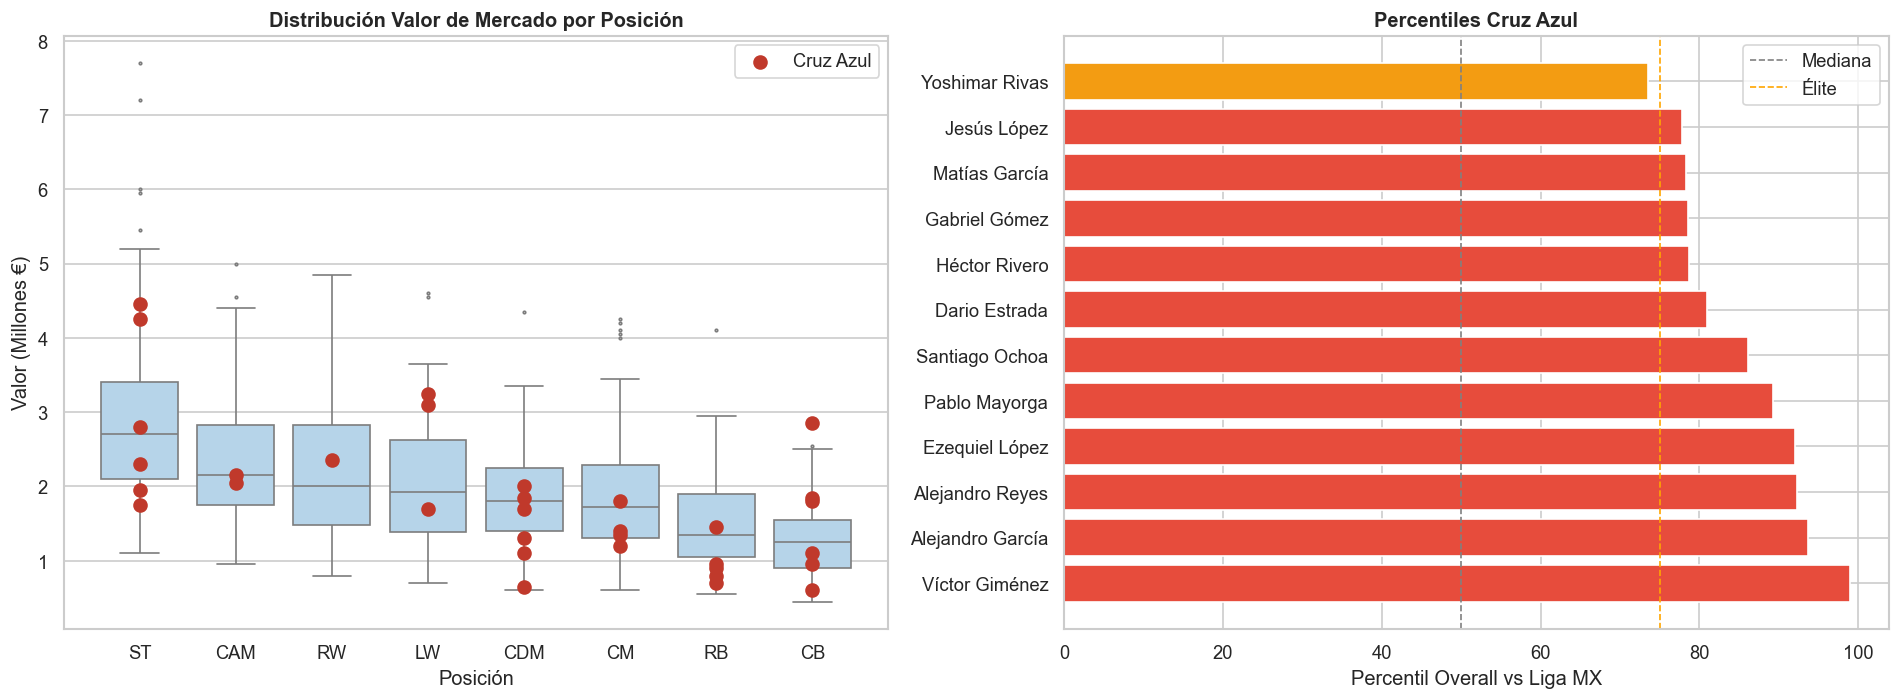


=== JUGADORES CRUZ AZUL — PERCENTIL & VALOR ===
         Jugador Pos  Edad  Overall Valor Mercado  Percentil
  Víctor Giménez  LW    35       84     EUR 3.1 M       98.9
Alejandro García  CM    32       83           N/A       93.7
 Alejandro Reyes  SS    33       83    EUR 3.35 M       92.3
  Ezequiel López  LW    34       82     EUR 1.7 M       92.0
   Pablo Mayorga  CM    33       82     EUR 1.4 M       89.2
  Santiago Ochoa  RB    36       81    EUR 0.95 M       86.1
   Dario Estrada  GK    25       83    EUR 1.75 M       81.0
   Héctor Rivero  ST    25       78           N/A       78.7
   Gabriel Gómez  LM    31       78     EUR 2.4 M       78.5
   Matías García  LB    23       79     EUR 1.8 M       78.3
     Jesús López  GK    17       82     EUR 1.1 M       77.8
  Yoshimar Rivas CDM    36       78     EUR 1.3 M       73.5
Santiago Vázquez  CB    26       79     EUR 1.8 M       73.3
Héctor Fernández  LW    22       76    EUR 3.25 M       70.5
    Diego García CDM    20       77 

In [ ]:
# filtramos los que sí tienen valor de mercado y lo pasamos a millones
df_valor = df[df['valor_mercado_eur'].notna() & (df['valor_mercado_eur'] > 0)].copy()
df_valor['vm_m'] = df_valor['valor_mercado_eur'] / 1e6

posiciones_top = df_valor['posicion'].value_counts().head(8).index.tolist()
df_v8 = df_valor[df_valor['posicion'].isin(posiciones_top)]
ca_valor = df_v8[es_ca(df_v8['equipo_norm'])]

orden = df_v8.groupby('posicion')['vm_m'].median().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graficamos el boxplot de valor
ax = axes[0]
sns.boxplot(data=df_v8, x='posicion', y='vm_m', order=orden, color='#AED6F1', fliersize=1.5, ax=ax)

# encimamos los puntos del cruz azul
flag_leyenda = False
for _, row in ca_valor.iterrows():
    if row['posicion'] in orden:
        idx = orden.index(row['posicion'])
        label = 'Cruz Azul' if not flag_leyenda else ''
        ax.scatter(idx, row['vm_m'], color='#C0392B', s=60, zorder=5, label=label)
        flag_leyenda = True
        
ax.set_title('Distribución Valor de Mercado por Posición', fontweight='bold')
ax.set_xlabel('Posición')
ax.set_ylabel('Valor (Millones €)')
ax.legend(loc='upper right')

# calculamos percentiles de FIFA Overall
df_ov = df[df['fifa_overall'].notna()].copy()
ca_ov = df_ov[es_ca(df_ov['equipo_norm'])].copy()

def saca_percentil(row, ref):
    peers = ref.loc[ref['posicion'] == row['posicion'], 'fifa_overall'].dropna()
    if len(peers) <= 1: return np.nan
    return round((peers < row['fifa_overall']).mean() * 100, 1)

ca_ov['pctil'] = ca_ov.apply(lambda r: saca_percentil(r, df_ov), axis=1)
top12 = ca_ov.nlargest(12, 'pctil')[['nombre_canonico', 'posicion', 'fifa_overall', 'pctil']].dropna()

ax2 = axes[1]
colores = ['#E74C3C' if p >= 75 else '#F39C12' if p >= 50 else '#3498DB' for p in top12['pctil']]
ax2.barh(top12['nombre_canonico'], top12['pctil'], color=colores)
ax2.axvline(50, color='gray', ls='--', lw=1, label='Mediana')
ax2.axvline(75, color='orange', ls='--', lw=1, label='Élite')
ax2.set_xlabel('Percentil Overall vs Liga MX')
ax2.set_title('Percentiles Cruz Azul', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# Tabla 
print('\n=== JUGADORES CRUZ AZUL — PERCENTIL & VALOR ===')
tabla = ca_ov[['nombre_canonico', 'posicion', 'edad', 'fifa_overall', 'valor_mercado_eur', 'pctil']].dropna(subset=['pctil'])
tabla = tabla.sort_values('pctil', ascending=False).copy()
tabla['valor_mercado_eur'] = tabla['valor_mercado_eur'].apply(lambda x: ('EUR ' + str(round(x / 1e6, 2)) + ' M') if pd.notna(x) else 'N/A')
tabla.columns = ['Jugador', 'Pos', 'Edad', 'Overall', 'Valor Mercado', 'Percentil']
print(tabla.head(15).to_string(index=False))

---
## P2 — ¿Cruz Azul rinde mejor en casa que fuera? ¿Cómo se compara con la liga?
> **Método:** Calculamos los puntos por partido (PPP) promedios en casa y fuera agrupando para cada equipo, para después realizar un ranking de ventaja local.  

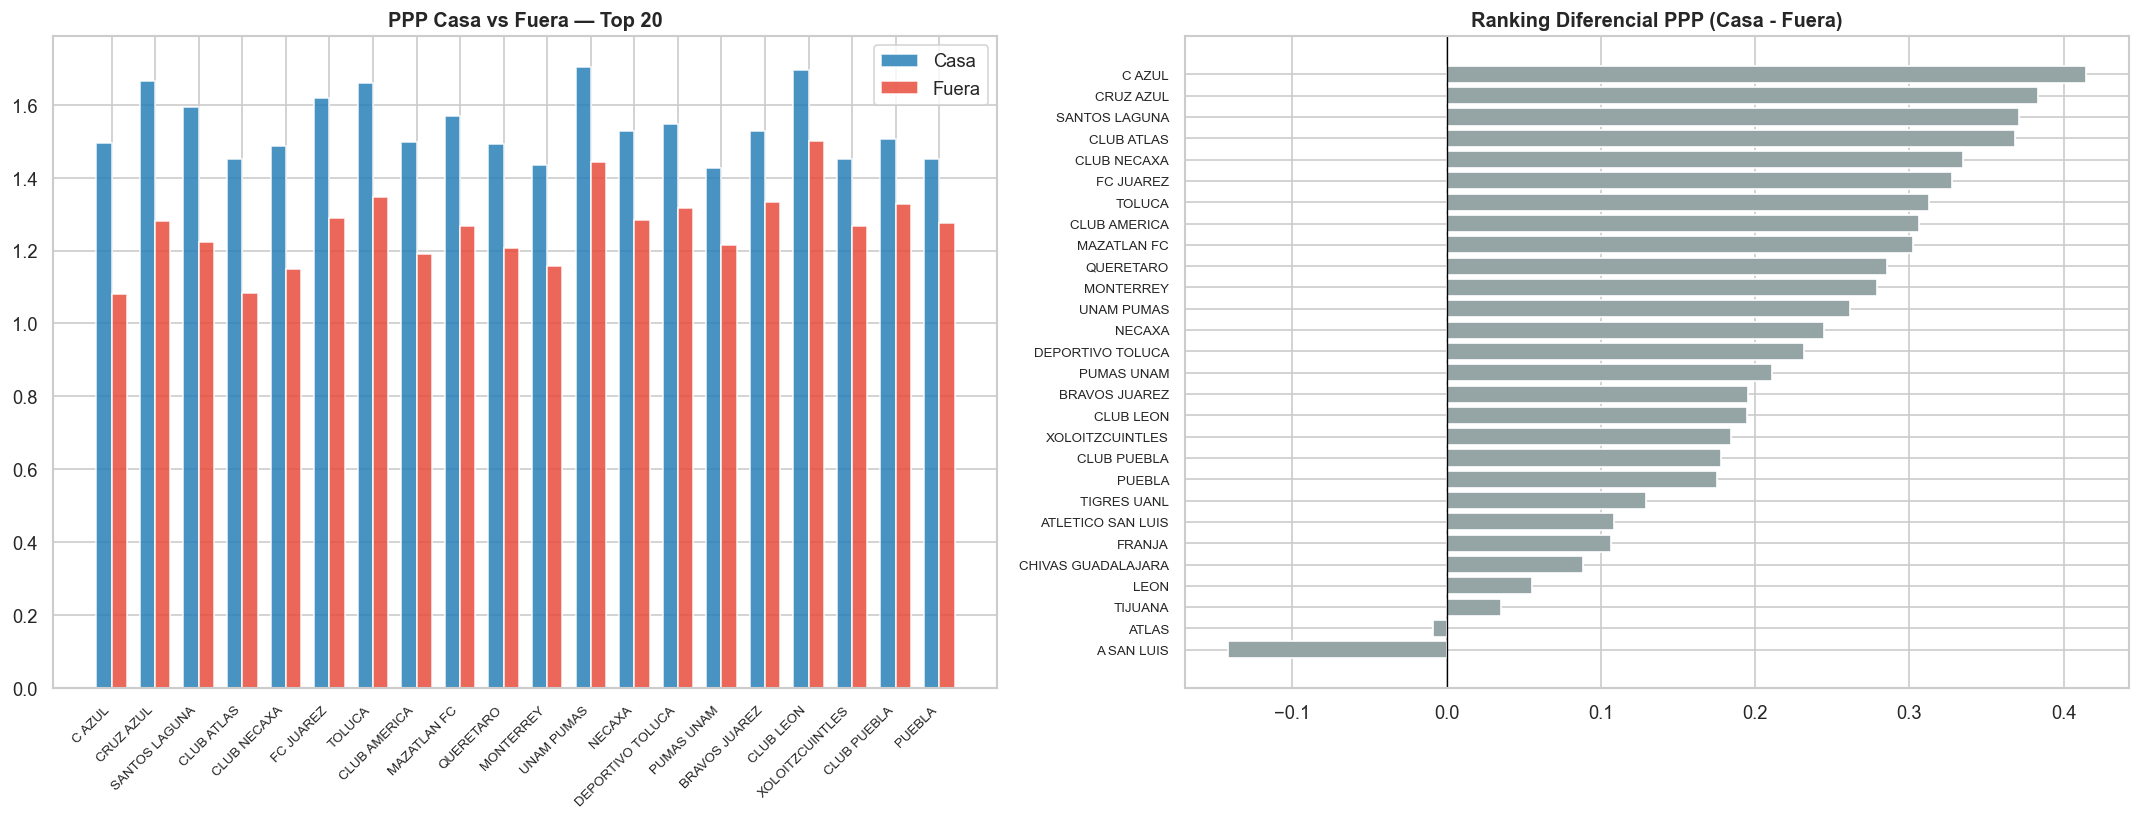

In [ ]:

def saca_puntos(res, es_local=True):
    if res == 'D': return 1
    if es_local: return 3 if res == 'W' else 0
    else: return 3 if res == 'L' else 0

partidos_limpios = partidos[partidos['resultado_local'].isin(['W', 'D', 'L'])].copy()
partidos_limpios['pts_local'] = partidos_limpios['resultado_local'].apply(lambda x: saca_puntos(x, True))
partidos_limpios['pts_visitante'] = partidos_limpios['resultado_local'].apply(lambda x: saca_puntos(x, False))

# Cálculo de los puntos medios
ppp_casa = partidos_limpios.groupby('equipo_local_norm')['pts_local'].mean().rename('Casa')
ppp_fuera = partidos_limpios.groupby('equipo_visitante_norm')['pts_visitante'].mean().rename('Fuera')

df_ventaja = pd.concat([ppp_casa, ppp_fuera], axis=1).dropna()
df_ventaja['Ventaja'] = df_ventaja['Casa'] - df_ventaja['Fuera']
df_ventaja.sort_values('Ventaja', ascending=False, inplace=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# graficamos el top 20
top20 = df_ventaja.head(20)
x = np.arange(len(top20))
w = 0.35

ax1.bar(x - w/2, top20['Casa'], w, label='Casa', color='#2980B9', alpha=0.85)
ax1.bar(x + w/2, top20['Fuera'], w, label='Fuera', color='#E74C3C', alpha=0.85)

# resaltamos al cruz azul
for i, team in enumerate(top20.index):
    if 'Cruz' in str(team):
        ax1.bar(i - w/2, top20.loc[team, 'Casa'], w, color='red')
        ax1.bar(i + w/2, top20.loc[team, 'Fuera'], w, color='red')
        
ax1.set_xticks(x)
ax1.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=8)
ax1.set_title('PPP Casa vs Fuera — Top 20', fontweight='bold')
ax1.legend()

# ranking de ventaja local
v_sorted = df_ventaja.sort_values('Ventaja', ascending=True)
colores_barras = ['#E74C3C' if 'Cruz' in str(t) else '#95A5A6' for t in v_sorted.index]

ax2.barh(range(len(v_sorted)), v_sorted['Ventaja'], color=colores_barras)
ax2.set_yticks(range(len(v_sorted)))
ax2.set_yticklabels(v_sorted.index, fontsize=8)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Ranking Diferencial PPP (Casa - Fuera)', fontweight='bold')

plt.tight_layout()
plt.show()



---
## P3 — ¿Cómo se comparan las métricas de desempeño de los jugadores extranjeros en comparación con los nacionales dentro del club?
> **Método:** Comparamos el valor de mercado, FIFA Overall y G+A/90 entre extranjeros y nacionales en Cruz Azul para contrastar con la liga.  

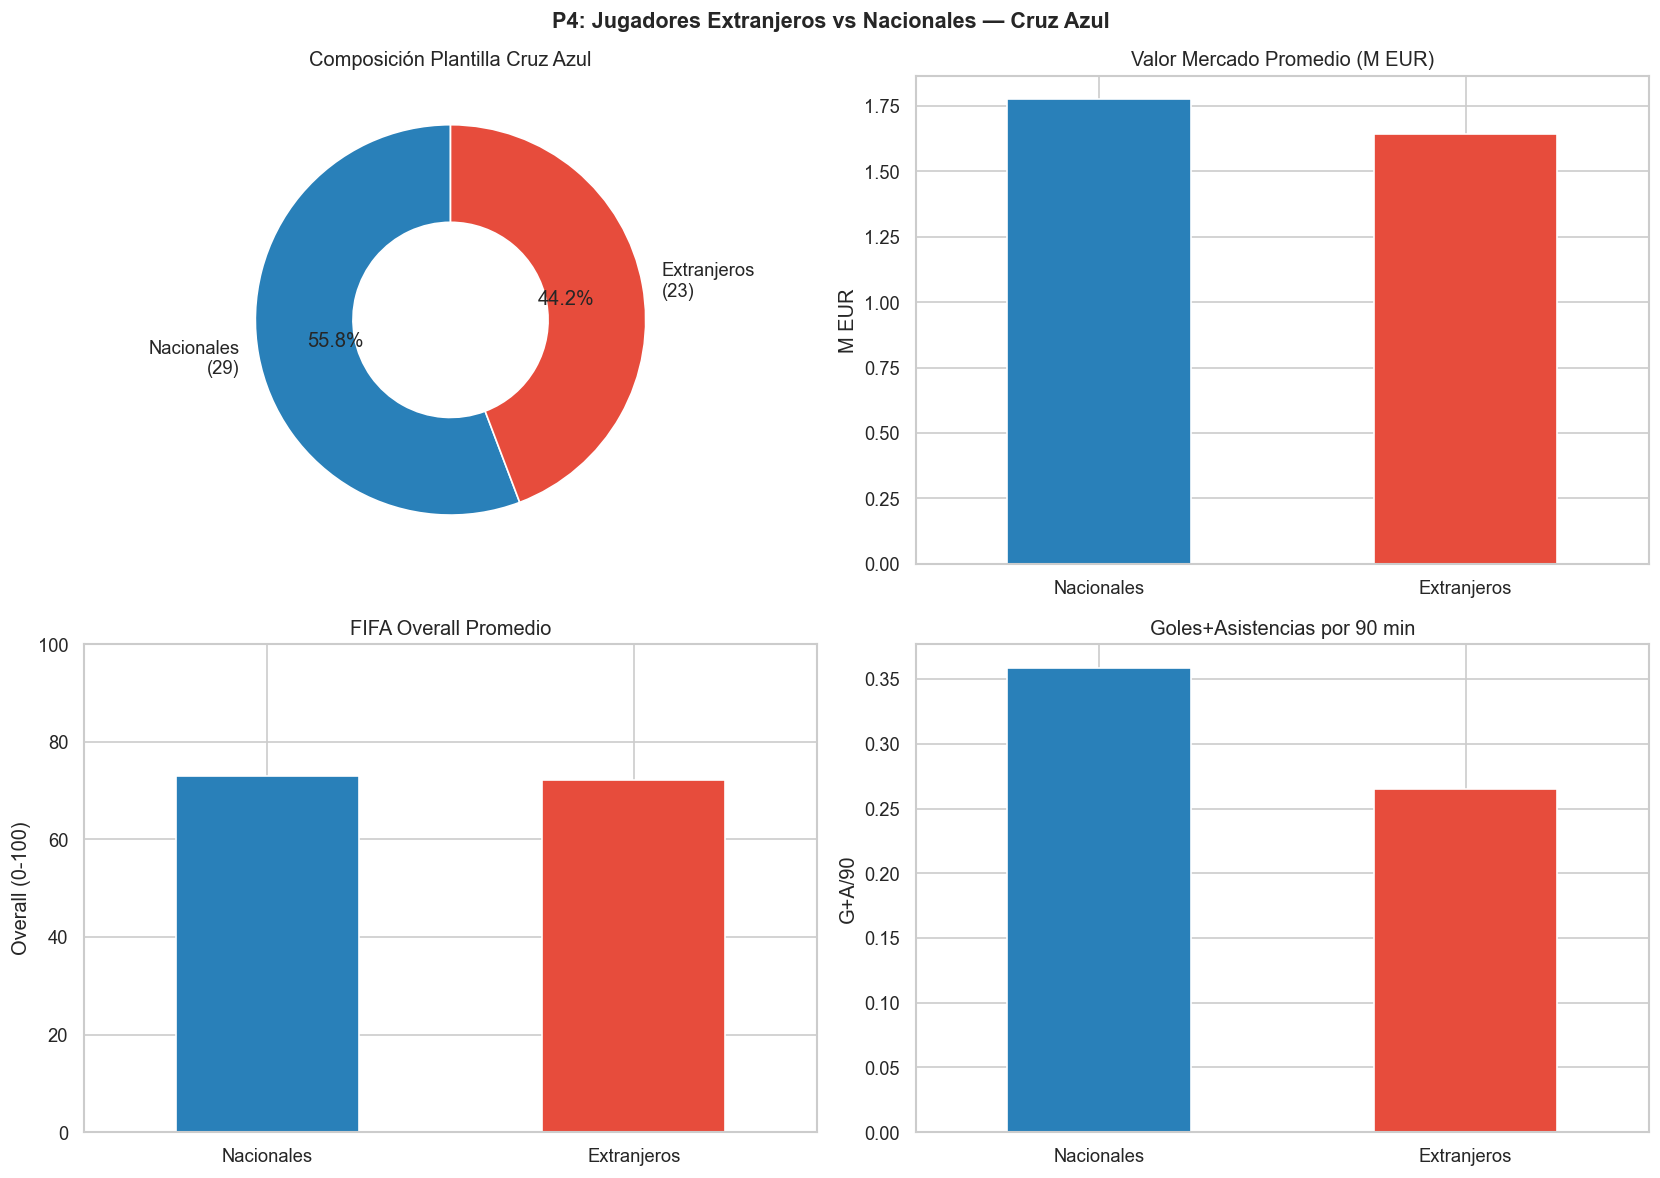


=== CRUZ AZUL: COMPARATIVA POR POSICIÓN Y ORIGEN ===
                      n  overall  valor_m  ga90
posicion extran                                
CAM      Nacionales   1    66.00     2.15  3.05
         Extranjeros  1    69.00     2.05  0.00
CB       Nacionales   4    71.75     1.30  0.13
         Extranjeros  2    73.00     1.98  0.16
CDM      Nacionales   3    70.67     1.50  0.20
         Extranjeros  3    71.33     1.37  0.41
CM       Nacionales   3    78.67     1.60  0.21
         Extranjeros  3    66.67     1.27  0.09
GK       Nacionales   4    78.50     1.19  0.07
         Extranjeros  2    79.50     1.42  0.21
LB       Nacionales   2    66.50     0.82  0.20
         Extranjeros  1    79.00     1.80  0.00
LM       Extranjeros  1    78.00     2.40  0.36
LW       Nacionales   1    84.00     3.10  0.13
         Extranjeros  3    76.33     2.48  0.59
RB       Nacionales   2    72.50     0.92  0.08
         Extranjeros  3    70.67     0.98  0.17
RM       Nacionales   2    66.50  

In [ ]:
CA4 = df[es_ca(df['equipo_norm'])].copy()
CA4['extran'] = CA4['es_extranjero'].fillna(False)

ext_count = int(CA4['extran'].sum())
nac_count = int((~CA4['extran']).sum())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.pie([nac_count, ext_count],
       labels=[f'Nacionales\n({nac_count})', f'Extranjeros\n({ext_count})'],
       colors=['#2980B9', '#E74C3C'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(width=0.5))
ax.set_title('Composición Plantilla Cruz Azul')

def media_seg(df_in, col):
    return df_in.groupby('extran')[col].mean()

def plot_bar_p4(ax, serie, title, ylabel, fmt=None):
    serie.index = ['Nacionales', 'Extranjeros']
    serie.plot(kind='bar', ax=ax, color=['#2980B9', '#E74C3C'], rot=0)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

#  Valor de mercado promedio
vm_ser = (CA4.groupby('extran')['valor_mercado_eur'].mean().fillna(0) / 1e6)
plot_bar_p4(axes[0, 1], vm_ser, 'Valor Mercado Promedio (M EUR)', 'M EUR')

# FIFA Overall promedio
ov_ser = media_seg(CA4, 'fifa_overall').fillna(0)
plot_bar_p4(axes[1, 0], ov_ser, 'FIFA Overall Promedio', 'Overall (0-100)')
axes[1, 0].set_ylim(0, 100)

# G+A por 90 min
ga_ser = media_seg(CA4, 'g_a_por_90').fillna(0)
plot_bar_p4(axes[1, 1], ga_ser, 'Goles+Asistencias por 90 min', 'G+A/90')
fig.suptitle('Jugadores Extranjeros vs Nacionales — Cruz Azul', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla comparativa 
print('\n=== CRUZ AZUL: COMPARATIVA POR POSICIÓN Y ORIGEN ===')
tabla_pos = CA4.groupby(['posicion', 'extran']).agg(
    n=('nombre_canonico', 'count'),
    overall=('fifa_overall', 'mean'),
    valor_m=('valor_mercado_eur', lambda x: x.mean() / 1e6),
    ga90=('g_a_por_90', 'mean')
).round(2)
tabla_pos.index = tabla_pos.index.set_levels(['Nacionales', 'Extranjeros'], level=1)
print(tabla_pos.to_string())

# Comparativa vs liga
print('\n=== LIGA MX: EXTRANJEROS vs NACIONALES ===')
liga_comp = df.copy()
liga_comp['extran'] = liga_comp['es_extranjero'].fillna(False)
liga_agg = liga_comp.groupby('extran').agg(
    n=('nombre_canonico', 'count'),
    overall=('fifa_overall', 'mean'),
    valor_m=('valor_mercado_eur', lambda x: x.dropna().mean() / 1e6),
    ga90=('g_a_por_90', 'mean')
).round(2)
liga_agg.index = ['Nacionales', 'Extranjeros']
print(liga_agg.to_string())

---
## P4 — ¿Qué equipos presentan mayor brecha entre valoración FIFA y valor Transfermarkt?
> **Método:** Normalizamos FIFA Overall y transformamos con log(Valor TM) a rango 0-1. Calculamos la brecha = FIFA_norm − TM_norm para posteriormente agregar por equipo.  

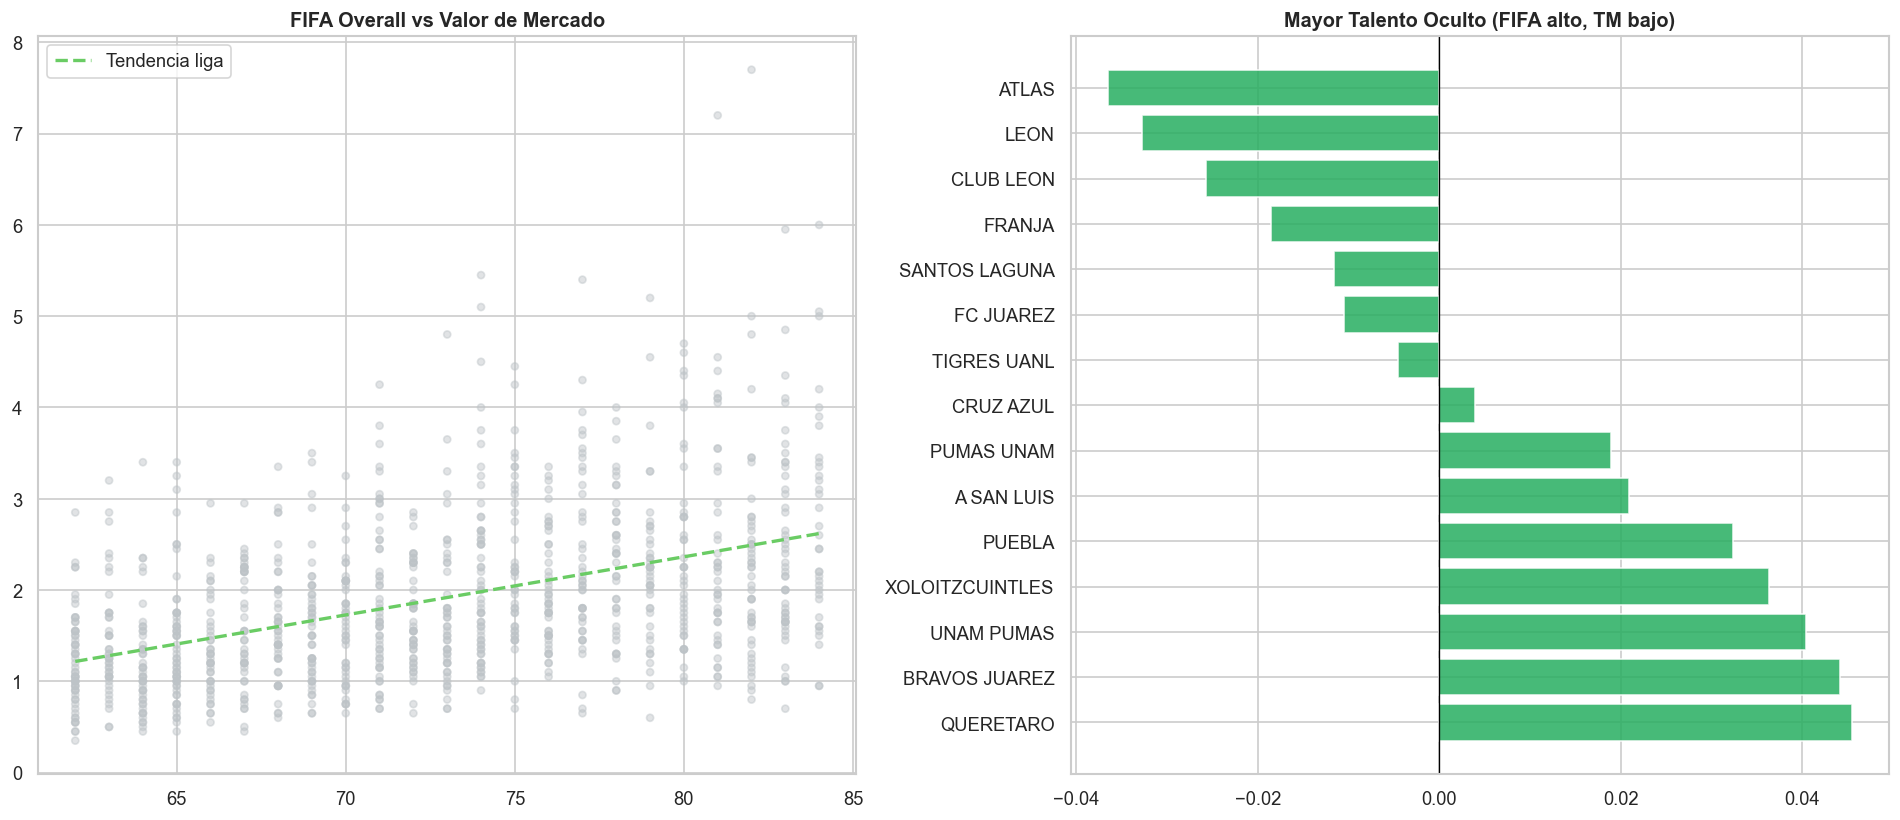


=== TOP 10 EQUIPOS CON MAYOR TALENTO OCULTO ===
    equipo_norm  brecha_media  n  overall_prom     vm_prom
      QUERETARO         0.045 68        74.544 1905882.353
  BRAVOS JUAREZ         0.044 24        73.167 1610416.667
     UNAM PUMAS         0.040 21        74.857 2145238.095
XOLOITZCUINTLES         0.036 23        73.696 1865217.391
         PUEBLA         0.032 19        72.316 1507894.737
     A SAN LUIS         0.021 20        72.950 1677500.000
     PUMAS UNAM         0.019 22        74.000 2011363.636
      CRUZ AZUL         0.004 47        72.553 1719148.936
    TIGRES UANL        -0.005 70        73.357 2013571.429
      FC JUAREZ        -0.011 49        73.163 1958163.265

=== TOP 10 JUGADORES SUBVALORADOS POR TRANSFERMARKT ===
    nombre_canonico   equipo_norm posicion  fifa_overall  valor_mercado_eur  brecha
Sebastián Rodríguez BRAVOS JUAREZ       GK            83               0.70   0.730
     Fernando Ochoa          LEON       CB            84               0.95  

In [ ]:
df_brecha = df[df['valor_mercado_eur'].notna() & df['fifa_overall'].notna() & (df['valor_mercado_eur'] > 0)].copy()

# normalizamos para poder compararlos 
scaler = MinMaxScaler()
df_brecha['ov_norm'] = scaler.fit_transform(df_brecha[['fifa_overall']])
df_brecha['vm_norm'] = scaler.fit_transform(np.log1p(df_brecha['valor_mercado_eur']).values.reshape(-1, 1))

# Índice de brecha: si es positivo, está subvalorado en TM
df_brecha['brecha'] = df_brecha['ov_norm'] - df_brecha['vm_norm']

brecha_equipos = df_brecha.groupby('equipo_norm').agg(
    brecha_media=('brecha', 'mean'),
    n=('nombre_canonico', 'count'),          
    overall_prom=('fifa_overall', 'mean'),   
    vm_prom=('valor_mercado_eur', 'mean')    
).reset_index()
brecha_equipos = brecha_equipos[brecha_equipos['n'] >= 5].sort_values('brecha_media', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# scatter plot
def asigna_color(t):
    if 'Cruz' in str(t): return '#E74C3C'
    if 'América' in str(t) or 'America' in str(t): return '#F39C12'
    if 'Monterrey' in str(t) or 'Rayados' in str(t): return '#2980B9'
    return '#BDC3C7'

colores_scatter = df_brecha['equipo_norm'].apply(asigna_color)
ax1.scatter(df_brecha['fifa_overall'], df_brecha['valor_mercado_eur'] / 1e6, c=colores_scatter, alpha=0.45, s=18)

# linea de tendencia de la liga
z = np.polyfit(df_brecha['fifa_overall'], df_brecha['valor_mercado_eur'] / 1e6, 1)
x_line = np.linspace(df_brecha['fifa_overall'].min(), df_brecha['fifa_overall'].max(), 100)
ax1.plot(x_line, np.poly1d(z)(x_line), 'g--', lw=2, label='Tendencia liga')
ax1.set_title('FIFA Overall vs Valor de Mercado', fontweight='bold')
ax1.legend()

# ranking de talento oculto
top_brecha = brecha_equipos.head(15)
colores_bar = ['#E74C3C' if 'Cruz' in str(t) else '#27AE60' for t in top_brecha['equipo_norm']]
ax2.barh(top_brecha['equipo_norm'], top_brecha['brecha_media'], color=colores_bar, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Mayor Talento Oculto (FIFA alto, TM bajo)', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== TOP 10 EQUIPOS CON MAYOR TALENTO OCULTO ===')
print(brecha_equipos[['equipo_norm', 'brecha_media', 'n', 'overall_prom', 'vm_prom']] 
      .head(10).round(3).to_string(index=False))

# Top 10 jugadores subvalorados en Liga MX
top_jug = df_brecha.nlargest(10, 'brecha')[['nombre_canonico', 'equipo_norm', 'posicion', 'fifa_overall', 'valor_mercado_eur', 'brecha']].copy()
top_jug['valor_mercado_eur'] = top_jug['valor_mercado_eur'] / 1e6
print('\n=== TOP 10 JUGADORES SUBVALORADOS POR TRANSFERMARKT ===')
print(top_jug.round(3).to_string(index=False))


---
## P5 — ¿Cómo evolucionará (2 años) el valor de mercado total de la plantilla de Cruz Azul temporada a temporada comparado con América y Rayados?
> **Método:** Proyectamos una serie de tiempo del valor acumulado de plantilla por temporada para Cruz Azul, América y Rayados y calculamos la variación porcentual entre temporadas. Posteriormente, usamos **Holt's Linear Smoothing** (suavización exponencial doble) para ajustar por equipo sobre la serie 2010–2024. Aprende nivel y tendencia vía optimización MLE, sin asumir estacionariedad, y proyecta **2025 y 2026** con intervalo de confianza del 90% (banda proporcional a √horizonte). Con ~15 puntos anuales y tendencia visible, esto permite capturar la dinámica sin sobreajustar. SARIMA requiere estacionariedad; Prophet necesita más densidad de puntos; LSTM es excesivo para esta escala.

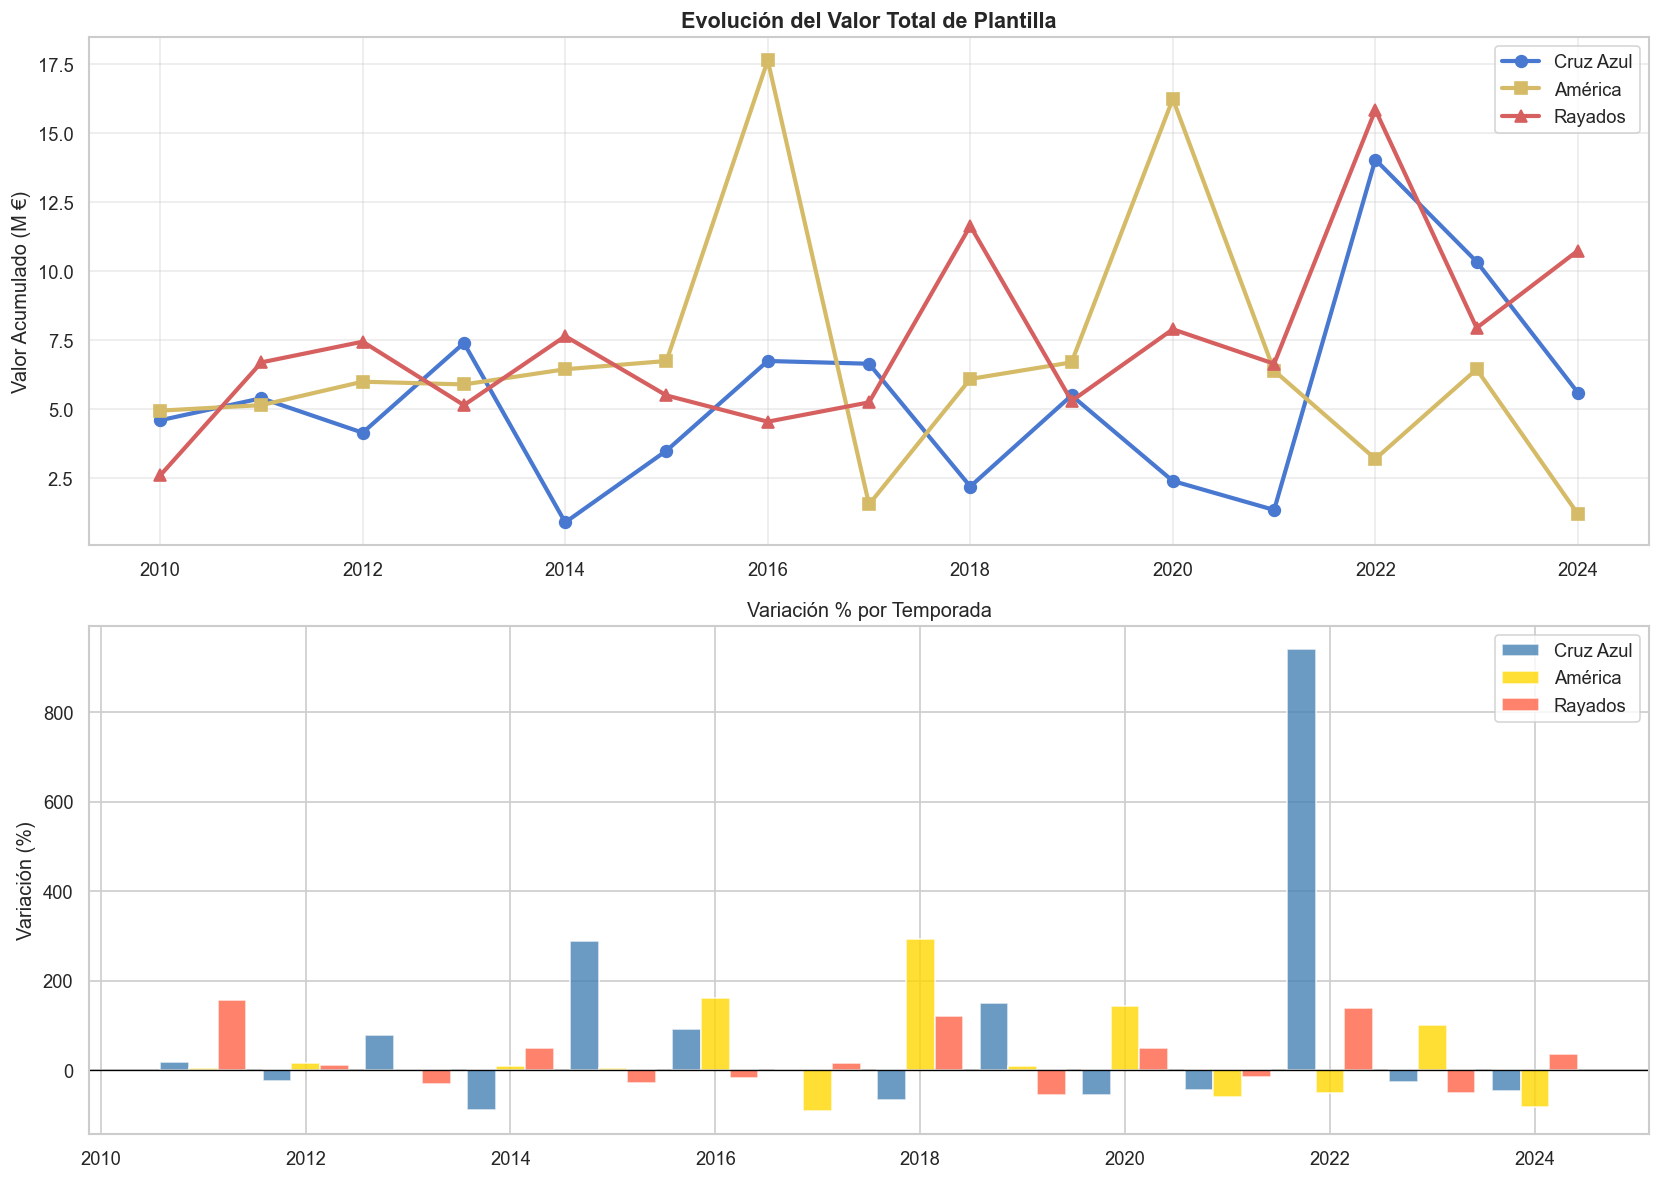


=== VALOR TOTAL DE PLANTILLA POR TEMPORADA (M EUR) ===
             Cruz Azul  América  Rayados
season_year                             
2010               4.6      5.0      2.6
2011               5.4      5.2      6.7
2012               4.2      6.0      7.4
2013               7.4      5.9      5.2
2014               0.9      6.4      7.6
2015               3.5      6.8      5.5
2016               6.8     17.6      4.6
2017               6.6      1.6      5.2
2018               2.2      6.1     11.6
2019               5.5      6.7      5.3
2020               2.4     16.2      7.9
2021               1.4      6.4      6.6
2022              14.0      3.2     15.8
2023              10.4      6.4      8.0
2024               5.6      1.2     10.8

=== VARIACIÓN PORCENTUAL ===
             Cruz Azul  América  Rayados
season_year                             
2011              17.4      4.0    157.7
2012             -23.1     16.5     11.2
2013              78.3     -1.7    -30.9
2014        

In [ ]:
df_hist = df[df['valor_mercado_eur'].notna() & (df['valor_mercado_eur'] > 0)].copy()

def valor_por_temp(mask):
    return df_hist[mask].groupby('season_year')['valor_mercado_eur'].sum() / 1e6

val_ca = valor_por_temp(es_ca(df_hist['equipo_norm']))
val_am = valor_por_temp(es_am(df_hist['equipo_norm']))
val_ray = valor_por_temp(es_ray(df_hist['equipo_norm']))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# calculamos las variaciones porcentuales (rendimientos)
pct_ca = val_ca.pct_change() * 100
pct_am = val_am.pct_change() * 100
pct_ray = val_ray.pct_change() * 100

w = 0.28
ax2.bar(pct_ca.dropna().index - w, pct_ca.dropna().values, w, label='Cruz Azul', color='steelblue', alpha=0.8)
ax2.bar(pct_am.dropna().index, pct_am.dropna().values, w, label='América', color='gold', alpha=0.8)
ax2.bar(pct_ray.dropna().index + w, pct_ray.dropna().values, w, label='Rayados', color='tomato', alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Variación % por Temporada', fontsize=12)
ax2.set_ylabel('Variación (%)')
ax2.legend()

plt.tight_layout()
plt.show()

print('\n=== VALOR TOTAL DE PLANTILLA POR TEMPORADA (M EUR) ===')
resumen = pd.DataFrame({'Cruz Azul': val_ca, 'América': val_am, 'Rayados': val_ray})
print(resumen.round(1).to_string())

print('\n=== VARIACIÓN PORCENTUAL ===')
resumen_pct = pd.DataFrame({'Cruz Azul': pct_ca, 'América': pct_am, 'Rayados': pct_ray})
print(resumen_pct.round(1).dropna().to_string())

c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: Value

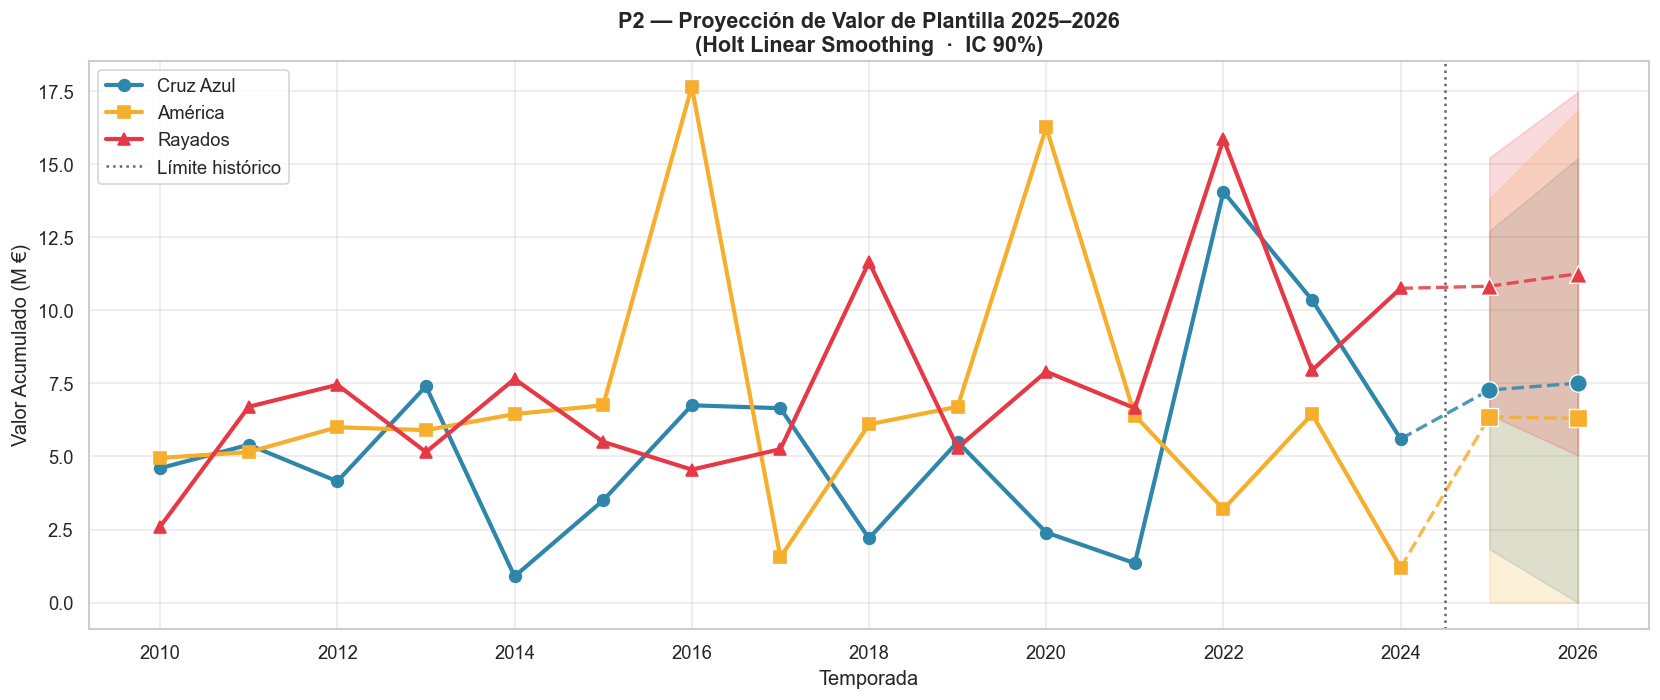


=== PROYECCIÓN (Holt Linear Smoothing) — VALOR DE PLANTILLA (M EUR) ===
      Cruz Azul  América  Rayados          Nota
2010        4.6      5.0      2.6              
2011        5.4      5.2      6.7              
2012        4.2      6.0      7.4              
2013        7.4      5.9      5.2              
2014        0.9      6.4      7.6              
2015        3.5      6.8      5.5              
2016        6.8     17.6      4.6              
2017        6.6      1.6      5.2              
2018        2.2      6.1     11.6              
2019        5.5      6.7      5.3              
2020        2.4     16.2      7.9              
2021        1.4      6.4      6.6              
2022       14.0      3.2     15.8              
2023       10.4      6.4      8.0              
2024        5.6      1.2     10.8              
2025        7.3      6.4     10.8  ← proyección
2026        7.5      6.3     11.3  ← proyección


In [ ]:

# Proyección 2 temporadas (2025–2026)
HORIZONTE = 2

def proyectar(serie, horizonte=HORIZONTE):
    serie = serie.sort_index().dropna()
    last_yr = int(serie.index[-1])
    fut_idx = np.arange(last_yr + 1, last_yr + horizonte + 1)

    if _backend == 'holt':
        model = HoltETS(
            serie, trend='add', seasonal=None,
            initialization_method='estimated'
        ).fit(optimized=True)
        fc = model.forecast(horizonte)
        fc.index = fut_idx
        sigma = model.resid.std()
    else:
        X = serie.index.values.reshape(-1, 1).astype(float)
        pipe = make_pipeline(PolynomialFeatures(2), LinearRegression())
        pipe.fit(X, serie.values)
        fc_vals = pipe.predict(fut_idx.reshape(-1, 1).astype(float))
        fc = pd.Series(fc_vals, index=fut_idx)
        sigma = (serie.values - pipe.predict(X)).std()

    # banda que crece con sqrt(horizonte)
    z90 = 1.645
    steps = np.arange(1, horizonte + 1)
    lower = (fc - z90 * sigma * np.sqrt(steps)).clip(lower=0)
    upper = fc + z90 * sigma * np.sqrt(steps)
    return fc, lower, upper

fc_ca, lo_ca, hi_ca = proyectar(val_ca)
fc_am, lo_am, hi_am = proyectar(val_am)
fc_ray, lo_ray, hi_ray = proyectar(val_ray)

fig, ax = plt.subplots(figsize=(14, 6))

series_cfg = [
    (val_ca, fc_ca, lo_ca, hi_ca, '#2E86AB', 'Cruz Azul', 'o'),
    (val_am, fc_am, lo_am, hi_am, '#F6AE2D', 'América', 's'),
    (val_ray, fc_ray, lo_ray, hi_ray, '#E63946', 'Rayados', '^'),
]

for hist, fc, lo, hi, color, label, marker in series_cfg:
    ax.plot(hist.index, hist.values, color=color, lw=2.5,
            marker=marker, ms=7, label=label)
    # línea punteada de proyección anclada al último punto histórico
    bridge_x = [hist.index[-1]] + fc.index.tolist()
    bridge_y = [hist.values[-1]] + fc.values.tolist()
    ax.plot(bridge_x, bridge_y, '--', color=color, lw=2, alpha=0.85)
    ax.scatter(fc.index, fc.values, color=color, marker=marker, s=110, zorder=5, edgecolors='white', linewidths=0.8)
    ax.fill_between(fc.index, lo.values, hi.values, color=color, alpha=0.18)

ax.axvline(2024.5, color='#666', ls=':', lw=1.5, label='Límite histórico')
modelo_str = 'Holt Linear Smoothing' if _backend == 'holt' else 'Regresión Polinómica'
ax.set_title(
    f'P2 — Proyección de Valor de Plantilla 2025–2026\n'
    f'({modelo_str}  ·  IC 90%)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Temporada')
ax.set_ylabel('Valor Acumulado (M €)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\n=== PROYECCIÓN ({modelo_str}) — VALOR DE PLANTILLA (M EUR) ===')
tabla_fc = pd.DataFrame({
    'Cruz Azul': pd.concat([val_ca,  fc_ca]),
    'América':   pd.concat([val_am,  fc_am]),
    'Rayados':   pd.concat([val_ray, fc_ray]),
})
tabla_fc.index = tabla_fc.index.astype(int)
tabla_fc.sort_index(inplace=True)
tabla_fc['Nota'] = ['← proyección' if y >= 2025 else '' for y in tabla_fc.index]
print(tabla_fc.round(1).to_string())


---
## P6 — ¿Qué jugadores de Liga MX tienen mayor probabilidad de ser transferidos en el próximo mercado de pases?
> **Método: Usamos un modelo **XGBoost** con `scale_pos_weight` para compensar el desbalance de clases. Tratamos el problema con features base (edad, overall, goles…) + **features delta YoY** como variación de valor de mercado, variación de Overall y años consecutivos en el mismo equipo.

Features usadas: ['edad', 'fifa_overall', 'log_valor', 'goles', 'asistencias', 'partidos', 'g_a_por_90', 'delta_valor', 'delta_overall', 'anos_equipo']
Registros tras calcular deltas : 269
No transferido: 217 | Transferido: 52

AUC-ROC en test: 0.4797


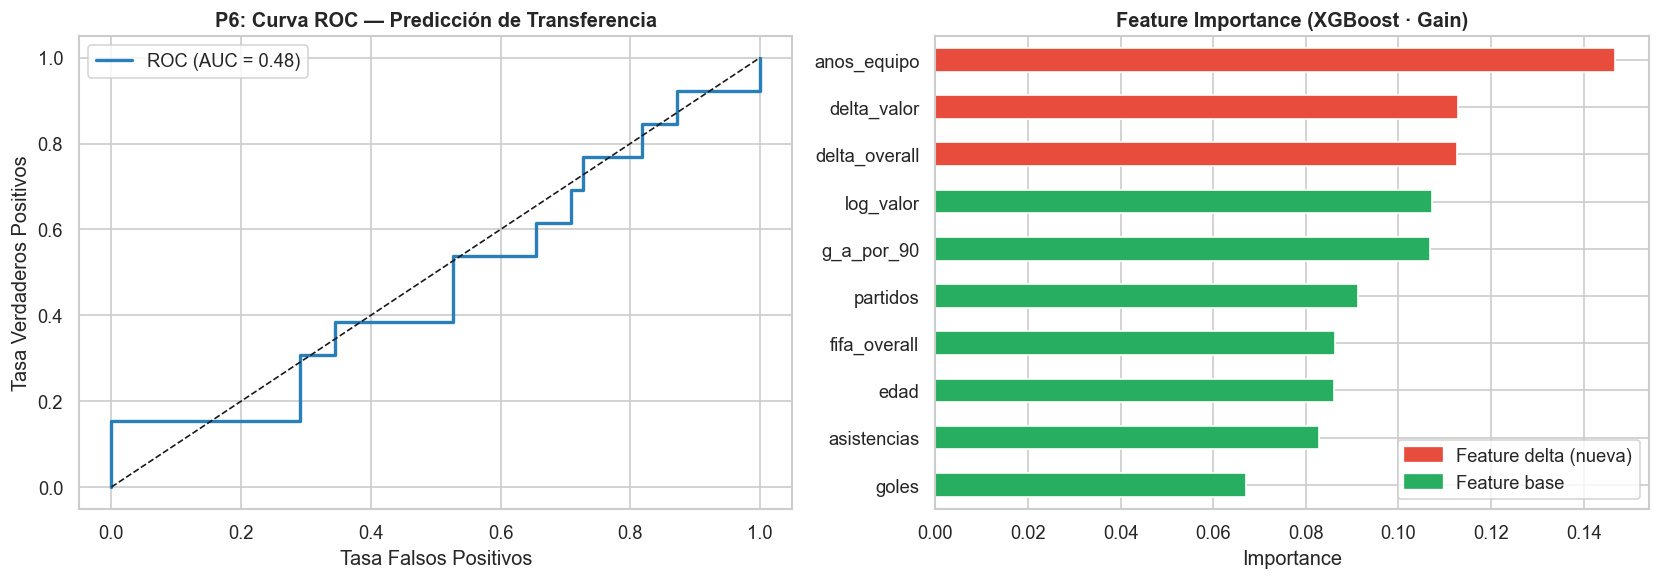


=== TOP 15 JUGADORES CON MAYOR PROBABILIDAD DE TRANSFERENCIA ===
  nombre_canonico        equipo_norm posicion  prob_transfer
     Roberto Romo          QUERETARO       RB          0.931
  Arturo Martínez       CLUB AMERICA       LW          0.922
Hirving Rodríguez        MAZATLAN FC       RM          0.671
   André Martínez        MAZATLAN FC       RB          0.643
 Lucas Villanueva CHIVAS GUADALAJARA       RW          0.640
  Yoshimar Torres        MAZATLAN FC      CAM          0.578
   Felipe Cáceres              ATLAS       ST          0.561
     Luis Vázquez        MAZATLAN FC       RB          0.510
  Jonathan Juárez               LEON       CM          0.491
 Ignacio Martínez          MONTERREY       LM          0.445
   Alexis Giménez        MAZATLAN FC       SS          0.433
 Santiago Vázquez             NECAXA       LM          0.406
    Roberto López          QUERETARO       RW          0.397
   Franco Estrada         UNAM PUMAS       CB          0.392
   Rodrigo Flores  

In [ ]:
from sklearn.metrics import roc_curve
from matplotlib.patches import Patch

# ─Creacion de features de variación y "Fidelidad"
cols_p6 = ['nombre_key', 'season_year', 'equipo_norm', 'edad', 'fifa_overall', 'valor_mercado_eur', 'goles', 'asistencias', 'partidos', 'g_a_por_90', 'posicion', 'nombre_canonico']
df_p6 = df[[c for c in cols_p6 if c in df.columns]].copy()
df_p6 = df_p6.sort_values(['nombre_key', 'season_year'])

# Target (Transferido/No transferido)
df_p6['equipo_next'] = df_p6.groupby('nombre_key')['equipo_norm'].shift(-1)
df_p6['transferido'] = (df_p6['equipo_next'].notna() & (df_p6['equipo_norm'] != df_p6['equipo_next'])).astype(int)

# Deltas YoY: capturan la trayectoria del jugador, no solo su estado actual
df_p6['delta_valor'] = df_p6.groupby('nombre_key')['valor_mercado_eur'].diff()
df_p6['delta_overall'] = df_p6.groupby('nombre_key')['fifa_overall'].diff()
df_p6['anos_equipo'] = df_p6.groupby(['nombre_key', 'equipo_norm']).cumcount() + 1
df_p6['log_valor'] = np.log1p(df_p6['valor_mercado_eur'])  # corrige asimetría

base_feats = ['edad', 'fifa_overall', 'log_valor', 'goles', 'asistencias', 'partidos', 'g_a_por_90']
delta_feats = ['delta_valor', 'delta_overall', 'anos_equipo']
features = [f for f in base_feats + delta_feats if f in df_p6.columns]

ml_df = df_p6[features + ['transferido', 'nombre_canonico', 'equipo_norm', 'posicion']].dropna(subset=features + ['transferido'])

X = ml_df[features].values
y = ml_df['transferido'].values

print('Features usadas:', features)
print(f'Registros tras calcular deltas : {len(ml_df)}')
print(f'No transferido: {(y==0).sum()} | Transferido: {(y==1).sum()}')

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scale_pw = (y_tr == 0).sum() / (y_tr == 1).sum()  # compensa desbalance de clases
xgb6 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pw,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb6.fit(X_tr, y_tr)
y_prob = xgb6.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, y_prob)
print(f'\nAUC-ROC en test: {round(auc, 4)}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_te, y_prob)
ax1.plot(fpr, tpr, color='#2980B9', lw=2, label=f'ROC (AUC = {round(auc, 3)})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('Tasa Falsos Positivos')
ax1.set_ylabel('Tasa Verdaderos Positivos')
ax1.set_title('P6: Curva ROC — Predicción de Transferencia', fontweight='bold')
ax1.legend()

# Feature importance coloreada: rojo = delta (nuevas), verde = base
imp = pd.Series(xgb6.feature_importances_, index=features).sort_values(ascending=True)
bar_colors = ['#E74C3C' if f in delta_feats else '#27AE60' for f in imp.index]
imp.plot(kind='barh', ax=ax2, color=bar_colors)
ax2.legend(handles=[
    Patch(color='#E74C3C', label='Feature delta'),
    Patch(color='#27AE60', label='Feature base')
], loc='lower right')
ax2.set_title('Feature Importance (XGBoost · Gain)', fontweight='bold')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()

ml_df2 = df_p6[features + ['nombre_canonico', 'equipo_norm', 'posicion']].dropna(subset=features).copy()
ml_df2['prob_transfer'] = xgb6.predict_proba(ml_df2[features].values)[:, 1]

last_idx = df_p6.sort_values('season_year').groupby('nombre_key').tail(1).index
candidates = ml_df2.loc[ml_df2.index.isin(last_idx)].sort_values('prob_transfer', ascending=False)

print('\n=== TOP 15 JUGADORES CON MAYOR PROBABILIDAD DE TRANSFERENCIA ===')
print(candidates[['nombre_canonico', 'equipo_norm', 'posicion', 'prob_transfer']]
      .head(15).round(3).to_string(index=False))

print('\n=== JUGADORES CRUZ AZUL — RANKING DE RIESGO ===')
ca_risk = candidates[es_ca(candidates['equipo_norm'])]
print(ca_risk[['nombre_canonico', 'posicion', 'prob_transfer']].head(10).round(3).to_string(index=False))


---
## P7 — ¿Cuál es el valor de mercado esperado dado el rendimiento real y atributos FIFA?
> **Método:** Calculado a través de XGBRegressor, tomando como target log(valor_mercado_eur). Features usadas: overall, potential, edad, posición codificada, goles, asistencias, minutos. 

RMSE (log-escala): 0.2721
R²              : 0.6948


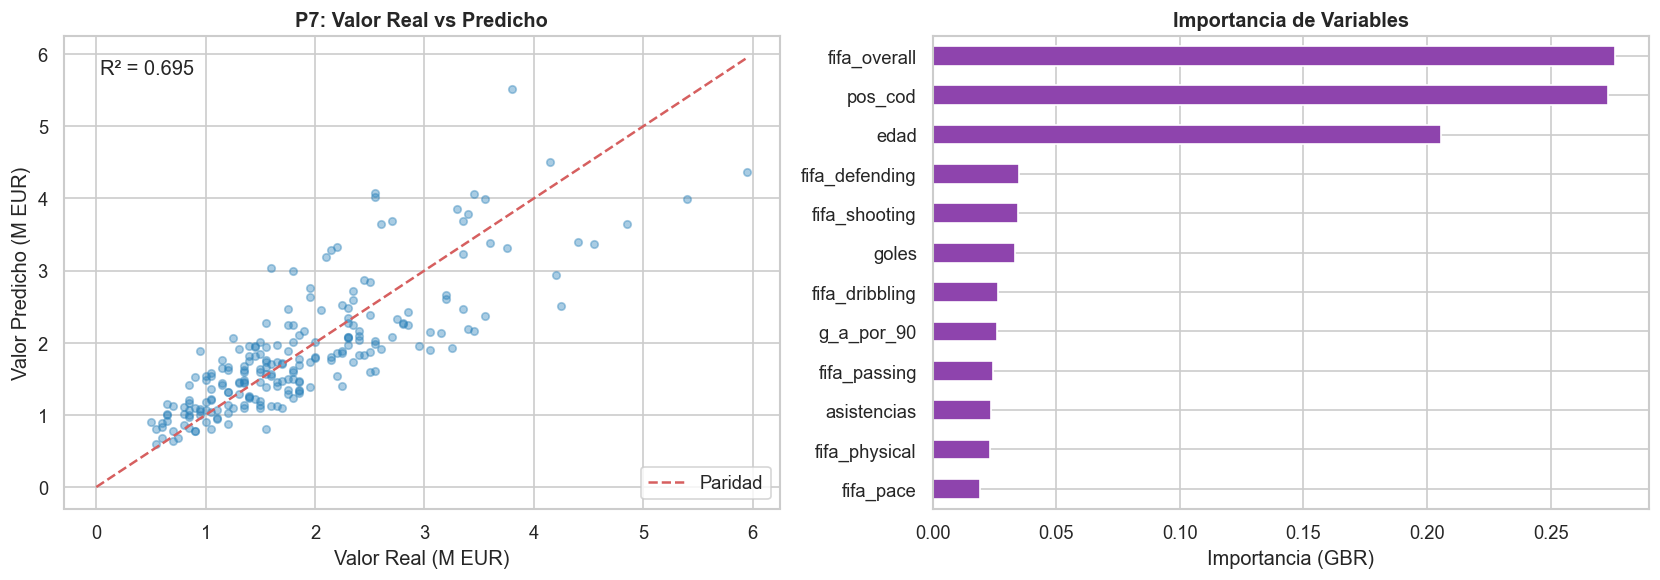


=== CRUZ AZUL: VALOR REAL vs ESPERADO POR EL MODELO ===
           Jugador Pos  Overall  Valor Real M  Valor Esperado M  Diferencia M
      Felipe Rivas  RM       66          1.00              1.54          0.54
     Matías García  LB       79          1.80              2.25          0.45
     Jonathan Mora  CM       74          1.20              1.62          0.42
       Luis Moreno  LB       68          0.60              0.89          0.29
      Pablo Torres  RB       71          0.70              0.98          0.28
     Pablo Mayorga  CM       82          1.40              1.66          0.26
      Hirving Romo  RM       66          1.35              1.59          0.24
    Dario Carneiro CDM       73          1.10              1.33          0.23
   Erick Hernández  LB       65          1.05              1.28          0.23
    Víctor Salcedo CDM       66          0.65              0.86          0.21
     Ramón Vázquez  GK       78          0.90              1.08          0.18
   Nico

In [ ]:
feats7 = ['fifa_overall', 'edad', 'goles', 'asistencias', 'minutos', 'g_a_por_90', 'fifa_pace', 'fifa_shooting', 'fifa_passing', 'fifa_dribbling', 'fifa_defending', 'fifa_physical']
feats7_present = [f for f in feats7 if f in df.columns]

df_p7 = df[feats7_present + ['valor_mercado_eur', 'posicion', 'nombre_canonico', 'equipo_norm']].copy()
df_p7 = df_p7[df_p7['valor_mercado_eur'].notna() & (df_p7['valor_mercado_eur'] > 0)].copy()

# Codificar posición
le = LabelEncoder()
df_p7['pos_cod'] = le.fit_transform(df_p7['posicion'].fillna('Unknown'))
features7 = feats7_present + ['pos_cod']

df_p7 = df_p7.dropna(subset=feats7_present)
df_p7['log_vm'] = np.log1p(df_p7['valor_mercado_eur'])

X7 = df_p7[features7].values
y7 = df_p7['log_vm'].values

X7_tr, X7_te, y7_tr, y7_te, idx7_tr, idx7_te = train_test_split(X7, y7, df_p7.index, test_size=0.2, random_state=42)

gbr = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
gbr.fit(X7_tr, y7_tr)
y7_pred = gbr.predict(X7_te)

rmse = np.sqrt(mean_squared_error(y7_te, y7_pred))
r2 = r2_score(y7_te, y7_pred)
print('RMSE (log-escala):', round(rmse, 4))
print('R²:', round(r2, 4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter predicho vs real 
y7_real_m = np.expm1(y7_te) / 1e6
y7_pred_m = np.expm1(y7_pred) / 1e6
ax1.scatter(y7_real_m, y7_pred_m, alpha=0.4, s=20, color='#2980B9')
lim = max(y7_real_m.max(), y7_pred_m.max())
ax1.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Paridad')
ax1.set_xlabel('Valor Real (M EUR)')
ax1.set_ylabel('Valor Predicho (M EUR)')
ax1.set_title('P7: Valor Real vs Predicho', fontweight='bold')
ax1.legend()
ax1.text(0.05, 0.92, 'R² = ' + str(round(r2, 3)), transform=ax1.transAxes)

imp7 = pd.Series(gbr.feature_importances_, index=features7).sort_values(ascending=True)
imp7.plot(kind='barh', ax=ax2, color='#8E44AD')
ax2.set_title('Importancia de Variables', fontweight='bold')
ax2.set_xlabel('Importancia (GBR)')

plt.tight_layout()
plt.show()

# Jugadores Cruz Azul: valor real vs esperado
ca_p7 = df_p7[es_ca(df_p7['equipo_norm'])].copy()
ca_p7['vm_esperado'] = np.expm1(gbr.predict(ca_p7[features7].values))
ca_p7['diferencia_m'] = (ca_p7['vm_esperado'] - ca_p7['valor_mercado_eur']) / 1e6
ca_p7['vm_real_m']    = ca_p7['valor_mercado_eur'] / 1e6
ca_p7['vm_esperado_m'] = ca_p7['vm_esperado'] / 1e6

print('\n=== CRUZ AZUL: VALOR REAL vs ESPERADO POR EL MODELO ===')
disp7 = ca_p7[['nombre_canonico', 'posicion', 'fifa_overall', 'vm_real_m', 'vm_esperado_m', 'diferencia_m']].sort_values('diferencia_m', ascending=False)
disp7.columns = ['Jugador', 'Pos', 'Overall', 'Valor Real M', 'Valor Esperado M', 'Diferencia M']
print(disp7.round(2).to_string(index=False))

---
## P8 — ¿Qué resultado puede esperarse en un partido de Cruz Azul?
> **Método:** **XGBoost binario** (`binary:logistic`). Target: **Victoria local (1) vs No victoria — empate o derrota — (0)**. Features: diferencial de Overall promedio entre plantillas, diferencial de forma reciente (pts), y diferencial de **forma goleadora** (goles a favor y en contra en últimos 5 partidos).
> **Evaluación:** AUC-ROC + Feature Importance (Gain).


Victoria local : 1453 (42.4%)
No victoria    : 1971 (57.6%)

AUC-ROC en test: 0.5358
              precision    recall  f1-score   support

 No Victoria       0.60      0.59      0.59       493
    Victoria       0.45      0.46      0.45       363

    accuracy                           0.53       856
   macro avg       0.52      0.52      0.52       856
weighted avg       0.53      0.53      0.53       856



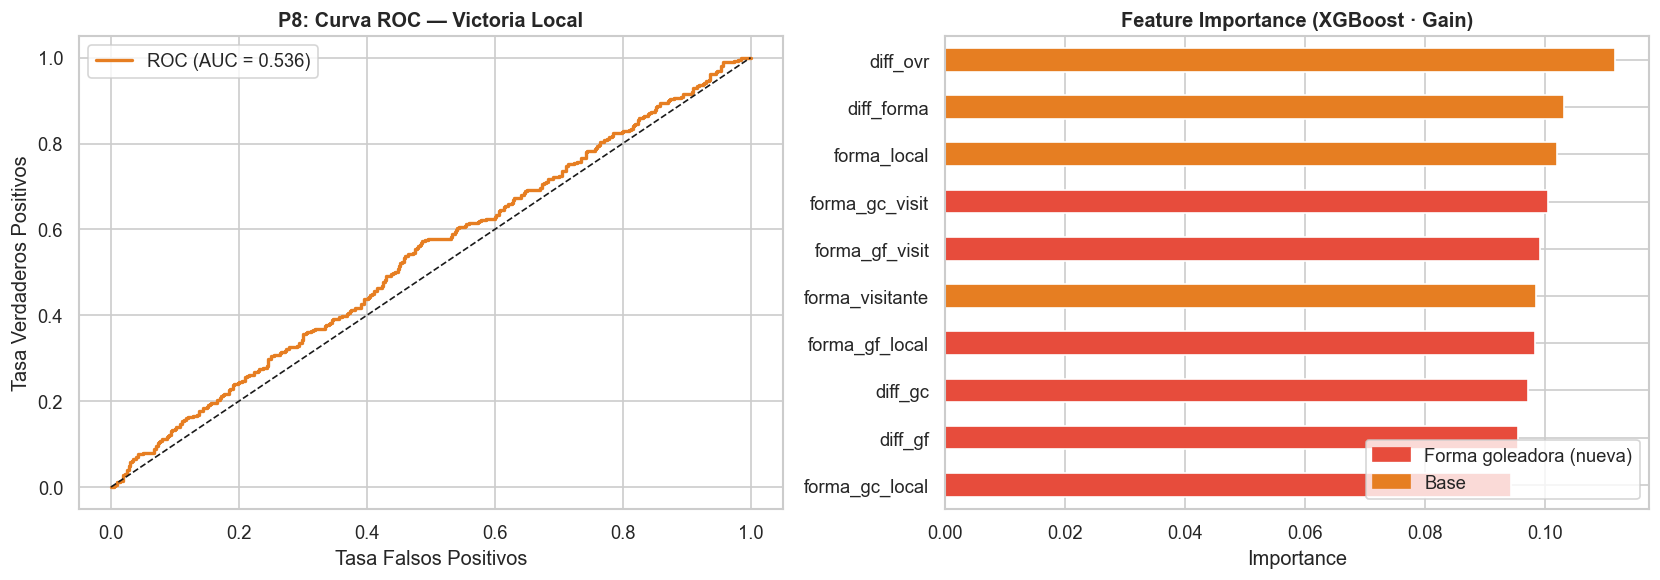


=== ÚLTIMO PARTIDO DE CRUZ AZUL ===
Victoria    : 66.8 %
No victoria : 33.2 %


In [ ]:
from sklearn.metrics import roc_curve
from matplotlib.patches import Patch

# Fuerza de plantilla por equipo y temporada 
squad_str = (df[df['fifa_overall'].notna()].groupby(['equipo_norm', 'season_year'])['fifa_overall'].mean().reset_index().rename(columns={'fifa_overall': 'squad_overall'}))

pt = partidos.copy()
pt['season_year'] = pt['season_year'].astype('Int64')
pt = pt.merge(squad_str.rename(columns={'equipo_norm': 'equipo_local_norm', 'squad_overall': 'ovr_local'}), on=['equipo_local_norm', 'season_year'], how='left')
pt = pt.merge(squad_str.rename(columns={'equipo_norm': 'equipo_visitante_norm', 'squad_overall': 'ovr_visit'}), on=['equipo_visitante_norm', 'season_year'], how='left')
pt['diff_ovr'] = pt['ovr_local'] - pt['ovr_visit']

pt_sorted = pt.sort_values('date').reset_index(drop=True)
pt_sorted['pts_local'] = pt_sorted['resultado_local'].map({'W': 3, 'D': 1, 'L': 0})
pt_sorted['pts_visitante'] = pt_sorted['resultado_local'].map({'W': 0, 'D': 1, 'L': 3})
 
# Registro largo: una fila por equipo por partido
home_rec = pt_sorted[['date', 'match_id', 'equipo_local_norm', 'pts_local', 'goles_local', 'goles_visitante']].rename(
    columns={'equipo_local_norm': 'equipo', 'pts_local': 'pts', 'goles_local': 'gf', 'goles_visitante': 'gc'})
away_rec = pt_sorted[['date', 'match_id', 'equipo_visitante_norm', 'pts_visitante', 'goles_visitante', 'goles_local']].rename(
    columns={'equipo_visitante_norm': 'equipo', 'pts_visitante': 'pts', 'goles_visitante': 'gf', 'goles_local': 'gc'})
hist = pd.concat([home_rec, away_rec]).sort_values(['equipo', 'date']).reset_index(drop=True)

# Si el partido actual no entra en su propia forma, evita filtración
for col in ['pts', 'gf', 'gc']:
    hist[f'forma_{col}'] = (hist.groupby('equipo')[col].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()))

forma = hist[['match_id', 'equipo', 'forma_pts', 'forma_gf', 'forma_gc']]

pt_sorted = pt_sorted.merge(forma.rename(columns={'equipo': 'equipo_local_norm', 'forma_pts': 'forma_local', 'forma_gf': 'forma_gf_local', 'forma_gc': 'forma_gc_local'}),
    on=['match_id', 'equipo_local_norm'], how='left')
pt_sorted = pt_sorted.merge(forma.rename(columns={'equipo': 'equipo_visitante_norm', 'forma_pts': 'forma_visitante', 'forma_gf': 'forma_gf_visit', 'forma_gc': 'forma_gc_visit'}),
    on=['match_id', 'equipo_visitante_norm'], how='left')

pt_sorted['diff_forma'] = pt_sorted['forma_local'] - pt_sorted['forma_visitante']
pt_sorted['diff_gf'] = pt_sorted['forma_gf_local'] - pt_sorted['forma_gf_visit']
pt_sorted['diff_gc'] = pt_sorted['forma_gc_local'] - pt_sorted['forma_gc_visit']

# Target binario: Victoria local (1) vs No victoria (0)
pt_sorted['gano_local'] = (pt_sorted['resultado_local'] == 'W').astype(int)

feats8 = ['diff_ovr', 'diff_forma', 'diff_gf', 'diff_gc', 'forma_local', 'forma_visitante', 'forma_gf_local', 'forma_gc_local', 'forma_gf_visit', 'forma_gc_visit']
feats8 = [f for f in feats8 if f in pt_sorted.columns]

df_ml8 = pt_sorted[feats8 + ['gano_local']].dropna()
X8 = df_ml8[feats8].values
y8 = df_ml8['gano_local'].values

print(f'Victoria local : {y8.sum()} ({y8.mean()*100:.1f}%)')
print(f'No victoria : {(1-y8).sum()} ({(1-y8).mean()*100:.1f}%)')

X8_tr, X8_te, y8_tr, y8_te = train_test_split(X8, y8, test_size=0.25, random_state=42, stratify=y8)

# Modelo: XGBoost binario
scale_pw8 = (y8_tr == 0).sum() / (y8_tr == 1).sum()
xgb_p8 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective='binary:logistic',
    scale_pos_weight=scale_pw8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_p8.fit(X8_tr, y8_tr)
y8_pred = xgb_p8.predict(X8_te)
y8_prob = xgb_p8.predict_proba(X8_te)[:, 1]

auc8 = roc_auc_score(y8_te, y8_prob)
print(f'\nAUC-ROC en test: {round(auc8, 4)}')
print(classification_report(y8_te, y8_pred, target_names=['No Victoria', 'Victoria']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fpr8, tpr8, _ = roc_curve(y8_te, y8_prob)
ax1.plot(fpr8, tpr8, color='#E67E22', lw=2, label=f'ROC (AUC = {round(auc8, 3)})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('Tasa Falsos Positivos')
ax1.set_ylabel('Tasa Verdaderos Positivos')
ax1.set_title('P8: Curva ROC — Victoria Local', fontweight='bold')
ax1.legend()

goal_feats = ['diff_gf', 'diff_gc', 'forma_gf_local', 'forma_gc_local', 'forma_gf_visit', 'forma_gc_visit']
imp8 = pd.Series(xgb_p8.feature_importances_, index=feats8).sort_values(ascending=True)
bar_colors8 = ['#E74C3C' if f in goal_feats else '#E67E22' for f in imp8.index]
imp8.plot(kind='barh', ax=ax2, color=bar_colors8)
ax2.legend(handles=[
    Patch(color='#E74C3C', label='Forma goleadora (nueva)'),
    Patch(color='#E67E22', label='Base')
], loc='lower right')
ax2.set_title('Feature Importance (XGBoost · Gain)', fontweight='bold')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()

# ── Predicción: último partido disponible de Cruz Azul ────────────────────────
ca_p8 = pt_sorted[es_ca(pt_sorted['equipo_local_norm']) |
                  es_ca(pt_sorted['equipo_visitante_norm'])].copy()
if len(ca_p8) > 0:
    sample = ca_p8[feats8].dropna().iloc[-1:]
    prob_win = xgb_p8.predict_proba(sample.values)[0][1]
    print(f'\n=== ÚLTIMO PARTIDO DE CRUZ AZUL ===')
    print(f'Victoria    : {prob_win*100:.1f} %')
    print(f'No victoria : {(1-prob_win)*100:.1f} %')


---
## P9 — ¿Qué mediocampista disponible en Liga MX maximiza rendimiento/costo ≤ 3 M USD?
> **Método:** Filtrar mediocampistas con valor ≤ 3 M USD. Índice compuesto ponderado: 40 % Overall + 30 % G+A/90 + 20 % Relación valor/rendimiento + 10 % Juventud.  
> **Visualización:** Tabla de recomendaciones + radar chart top candidato vs Cruz Azul.

Mediocampistas disponibles (excl. Cruz Azul, VM <= 3M USD): 262

=== TOP 5 MEDIOCAMPISTAS RECOMENDADOS PARA CRUZ AZUL ===
             Jugador             Equipo Pos  Edad  Overall  G+A/90  Valor (M EUR)  Índice
Sebastián Villanueva CHIVAS GUADALAJARA  CM    35       82   2.762           1.90   0.753
        Jesús Torres      SANTOS LAGUNA CDM    18       84   0.239           1.50   0.637
       Leandro Lotti      BRAVOS JUAREZ CAM    36       83   0.828           1.45   0.598
    Jonathan Álvarez      BRAVOS JUAREZ  CM    17       83   0.408           2.15   0.582
        Diego Torres              ATLAS  CM    31       79   1.636           2.05   0.582


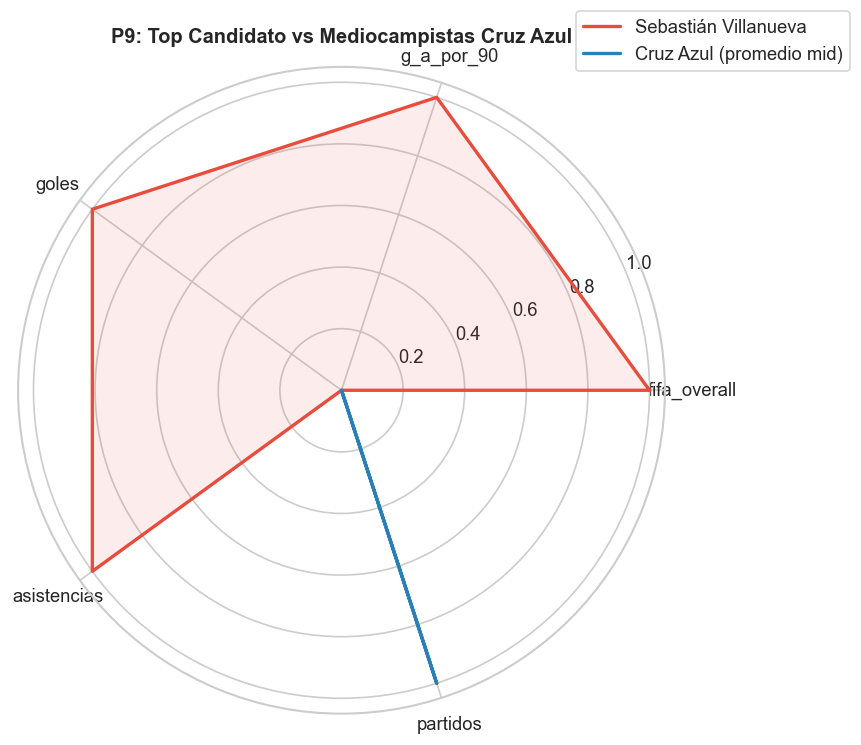

In [11]:

BUDGET_USD = 3_000_000
EUR_USD    = 1.08
BUDGET_EUR = BUDGET_USD / EUR_USD

# Posiciones de mediocampo
mid_kw = ['CM', 'CDM', 'CAM', 'MC', 'MCD', 'MCC', 'MCO', 'MI', 'MD',
          'Centrocampista', 'Mediocamp', 'MF', 'DM', 'AM']
mid_pattern = '|'.join(mid_kw)

mids = df[
    df['posicion'].str.contains(mid_pattern, case=False, na=False) &
    df['valor_mercado_eur'].notna() &
    (df['valor_mercado_eur'] > 0) &
    (df['valor_mercado_eur'] <= BUDGET_EUR) &
    ~es_ca(df['equipo_norm'])
].copy()

print('Mediocampistas disponibles (excl. Cruz Azul, VM <= 3M USD):', len(mids))

if len(mids) == 0:
    print('Sin coincidencias exactas — ampliando presupuesto x2')
    mids = df[
        df['posicion'].str.contains(mid_pattern, case=False, na=False) &
        df['valor_mercado_eur'].notna() &
        (df['valor_mercado_eur'] > 0) &
        (df['valor_mercado_eur'] <= BUDGET_EUR * 2) &
        ~es_ca(df['equipo_norm'])
    ].copy()

# Índice compuesto
mids_clean = mids.dropna(subset=['fifa_overall', 'g_a_por_90']).copy()
sc = MinMaxScaler()

mids_clean['ov_n']   = sc.fit_transform(mids_clean[['fifa_overall']])
mids_clean['ga_n']   = sc.fit_transform(mids_clean[['g_a_por_90']].fillna(0))
vm_n_vals = 1 - sc.fit_transform(mids_clean[['valor_mercado_eur']])
mids_clean['vm_n']   = vm_n_vals
mids_clean['edad_n'] = 1 - sc.fit_transform(mids_clean[['edad']].fillna(30))

mids_clean['indice'] = (0.40 * mids_clean['ov_n'] +
                        0.30 * mids_clean['ga_n'] +
                        0.20 * mids_clean['vm_n'] +
                        0.10 * mids_clean['edad_n'])

top5 = mids_clean.nlargest(5, 'indice')[['nombre_canonico', 'equipo_norm', 'posicion',
                                          'edad', 'fifa_overall', 'g_a_por_90',
                                          'valor_mercado_eur', 'indice']].copy()
top5['valor_mercado_eur'] = top5['valor_mercado_eur'] / 1e6

print('\n=== TOP 5 MEDIOCAMPISTAS RECOMENDADOS PARA CRUZ AZUL ===')
top5_disp = top5.copy()
top5_disp.columns = ['Jugador', 'Equipo', 'Pos', 'Edad', 'Overall',
                      'G+A/90', 'Valor (M EUR)', 'Índice']
print(top5_disp.round(3).to_string(index=False))

#  top candidato vs mediocampistas de Cruz Azul
radar_feats = [f for f in ['fifa_overall', 'g_a_por_90', 'goles', 'asistencias', 'partidos']
               if f in df.columns]
ca_mids = df[
    es_ca(df['equipo_norm']) &
    df['posicion'].str.contains(mid_pattern, case=False, na=False)
][radar_feats + ['nombre_canonico']].dropna()

if len(top5) > 0 and len(ca_mids) > 0:
    cand_name = top5.iloc[0]['nombre_canonico']
    cand_rows = mids_clean[mids_clean['nombre_canonico'] == cand_name][radar_feats]
    if len(cand_rows) == 0:
        cand_rows = mids_clean[radar_feats].iloc[[0]]
    cand_row = cand_rows.iloc[0]
    ca_mean  = ca_mids[radar_feats].mean()

    sc_r = MinMaxScaler()
    combined = pd.DataFrame([cand_row.values, ca_mean.values], columns=radar_feats)
    combined_n = pd.DataFrame(sc_r.fit_transform(combined), columns=radar_feats)

    angles = np.linspace(0, 2 * np.pi, len(radar_feats), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax_r = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for i, (label, color) in enumerate(zip(
            [cand_name, 'Cruz Azul (promedio mid)'], ['#E74C3C', '#2980B9'])):
        vals = combined_n.iloc[i].tolist() + [combined_n.iloc[i].tolist()[0]]
        ax_r.plot(angles, vals, color=color, lw=2, label=label)
        ax_r.fill(angles, vals, color=color, alpha=0.1)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(radar_feats)
    ax_r.set_title('P9: Top Candidato vs Mediocampistas Cruz Azul', fontweight='bold', pad=15)
    ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

---
## P10 — ¿Qué debilidades tácticas tiene Cruz Azul y qué perfil de jugador necesita?
> **Método:** Analizar goles concedidos por jornada en partidos de Cruz Azul. Comparar atributos defensivos FIFA vs los 3 equipos más sólidos de la liga. Identificar perfil y candidatos.  
> **Visualización:** Heatmap de goles concedidos + radar defensivo comparativo.

Equipos más sólidos defensivamente: ['TOLUCA', 'CLUB LEON', 'LEON']
Goles concedidos promedio por partido:
TOLUCA       1.378
CLUB LEON    1.392
LEON         1.440
Name: gc_total, dtype: float64

Cruz Azul — goles concedidos promedio por partido: 1.603


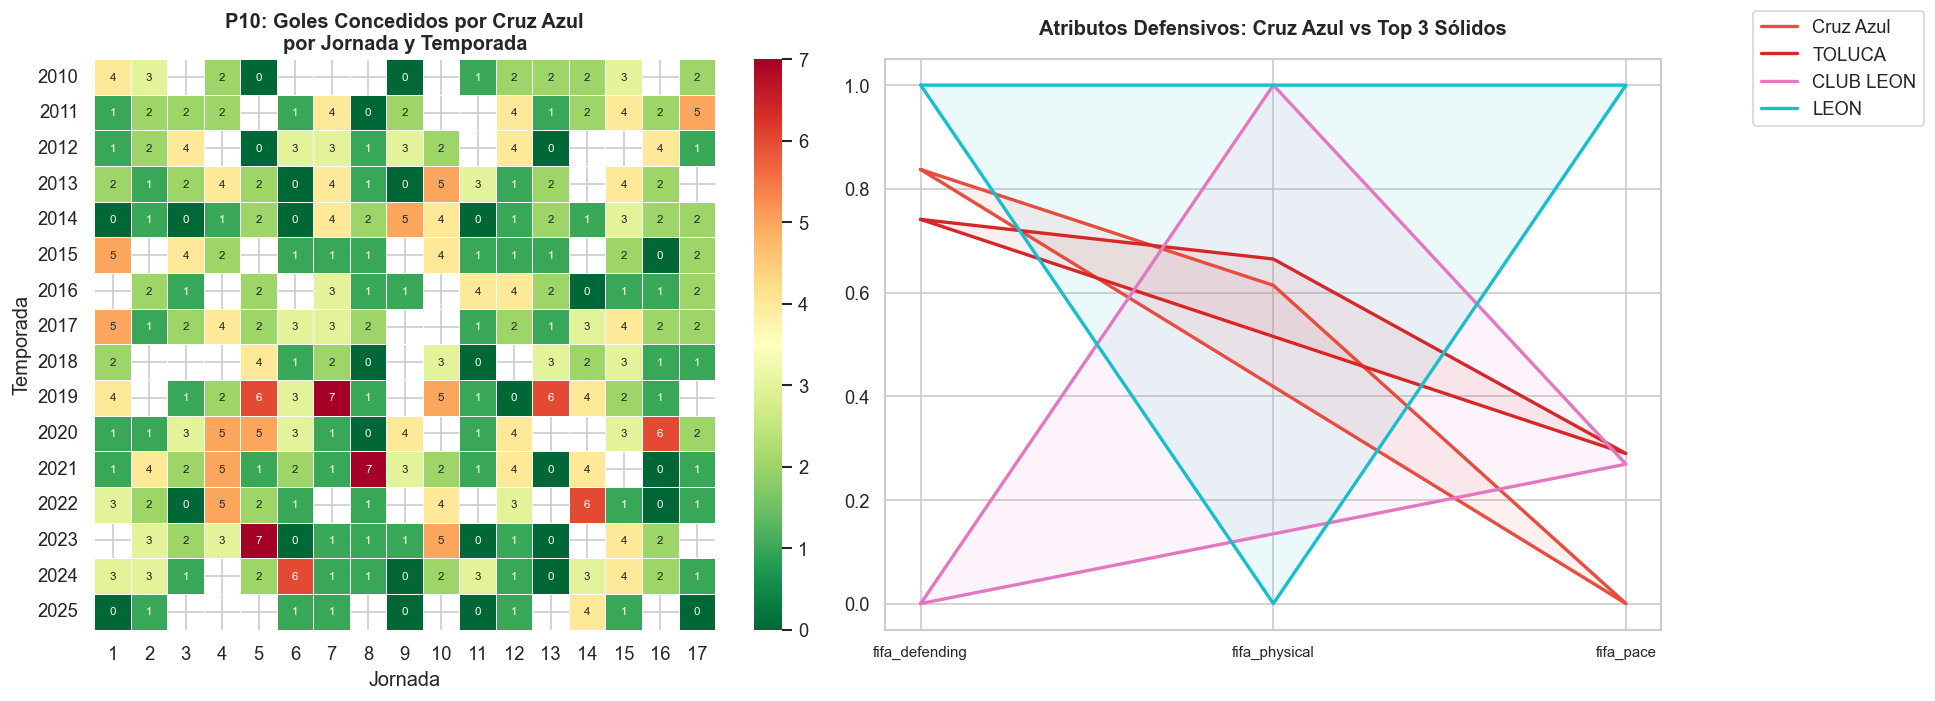


=== PERFIL DEFENSIVO NECESARIO PARA CRUZ AZUL ===
Gap atributos defensivos (Top3 - Cruz Azul):
fifa_defending   -1.1
fifa_physical    -0.2
fifa_pace         3.3

=== TOP 10 CANDIDATOS DEFENSIVOS DISPONIBLES (VM <= 5M EUR) ===
  nombre_canonico        equipo_norm posicion  edad  defending  overall  Valor M
     Héctor Rivas        TIGRES UANL      CDM    28         85       83     4.35
Rodrigo Fernández CHIVAS GUADALAJARA       CB    33         85       82     1.90
 Fernando Álvarez       CLUB AMERICA      CDM    26         85       82     2.65
     Lucas Suárez            TIJUANA       CB    17         85       71     0.80
   Guillermo Romo  ATLETICO SAN LUIS      CDM    25         85       79     2.70
 Gabriel Martínez        MAZATLAN FC       CB    18         85       64     0.80
     Jorge Lozano      SANTOS LAGUNA       RB    30         85       70     1.05
     Marco Moreno      BRAVOS JUAREZ      CDM    21         85       66     0.95
     Ramón Macías   DEPORTIVO TOLUCA       C

In [12]:

# Goles concedidos por Cruz Azul por temporada/jornada
ca_local = partidos[es_ca(partidos['equipo_local_norm'])].copy()
ca_visit = partidos[es_ca(partidos['equipo_visitante_norm'])].copy()

ca_local['goles_concedidos'] = ca_local['goles_visitante']
ca_local['goles_favor']      = ca_local['goles_local']
ca_visit['goles_concedidos'] = ca_visit['goles_local']
ca_visit['goles_favor']      = ca_visit['goles_visitante']

ca_all = pd.concat([ca_local[['season_year', 'round', 'goles_concedidos', 'goles_favor']],
                    ca_visit[['season_year', 'round', 'goles_concedidos', 'goles_favor']]])
ca_all = ca_all.dropna(subset=['goles_concedidos', 'season_year', 'round'])
ca_all['season_year'] = ca_all['season_year'].astype(int)
ca_all['round']       = ca_all['round'].astype(int)

# Heatmap goles concedidos por jornada/temporada
pivot_gc = ca_all.pivot_table(index='season_year', columns='round',
                               values='goles_concedidos', aggfunc='sum')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_gc, cmap='RdYlGn_r', ax=ax1,
            linewidths=0.3, annot=True, fmt='.0f', annot_kws={'size': 7})
ax1.set_title('P10: Goles Concedidos por Cruz Azul\npor Jornada y Temporada', fontweight='bold')
ax1.set_xlabel('Jornada')
ax1.set_ylabel('Temporada')

# Cruz Azul vs top 3 defensivos de la liga
def_feats = ['fifa_defending', 'fifa_physical', 'fifa_pace']
def_feats_ok = [f for f in def_feats if f in df.columns]

# Equipos que menos goles conceden (promedio por partido)
gc_eq_local = (partidos.groupby('equipo_local_norm')['goles_visitante']
               .mean().rename('gc_local'))
gc_eq_visit = (partidos.groupby('equipo_visitante_norm')['goles_local']
               .mean().rename('gc_visit'))
gc_eq = pd.concat([gc_eq_local, gc_eq_visit], axis=1)
gc_eq['gc_total'] = gc_eq.mean(axis=1)
top3_def = gc_eq.nsmallest(3, 'gc_total').index.tolist()

print('Equipos más sólidos defensivamente:', top3_def)
print('Goles concedidos promedio por partido:')
print(gc_eq.loc[top3_def, 'gc_total'].round(3))

ca_gc = ca_all['goles_concedidos'].mean()
print('\nCruz Azul — goles concedidos promedio por partido:', round(ca_gc, 3))

# Radar defensivo
if len(def_feats_ok) > 0:
    def_df = df[def_feats_ok + ['equipo_norm']].dropna()

    groups_names = ['Cruz Azul'] + [t for t in top3_def]
    groups_masks = [es_ca(def_df['equipo_norm'])] + [
        def_df['equipo_norm'].str.contains(t.split()[0], case=False, na=False)
        for t in top3_def]

    profiles = []
    valid_names = []
    for name, mask in zip(groups_names, groups_masks):
        sub = def_df[mask][def_feats_ok]
        if len(sub) > 0:
            profiles.append(sub.mean().values)
            valid_names.append(name)

    if len(profiles) > 1:
        sc_r2 = MinMaxScaler()
        profiles_n = sc_r2.fit_transform(np.array(profiles))

        angles2 = np.linspace(0, 2 * np.pi, len(def_feats_ok), endpoint=False).tolist()
        angles2 += angles2[:1]
        cmap = plt.cm.get_cmap('tab10', len(valid_names))

        for i, (name, pn) in enumerate(zip(valid_names, profiles_n)):
            vals2 = pn.tolist() + [pn[0]]
            color2 = '#E74C3C' if 'Cruz' in name else cmap(i)
            ax2.plot(angles2, vals2, color=color2, lw=2, label=name)
            ax2.fill(angles2, vals2, color=color2, alpha=0.08)

        ax2.set_xticks(angles2[:-1])
        ax2.set_xticklabels(def_feats_ok, fontsize=9)
        ax2.set_title('Atributos Defensivos: Cruz Azul vs Top 3 Sólidos', fontweight='bold', pad=15)
        ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
    else:
        ax2.text(0.5, 0.5, 'Datos insuficientes para radar', ha='center', transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, 'Columnas FIFA defensivas no disponibles', ha='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

# Perfil del jugador a fichar y candidatos
print('\n=== PERFIL DEFENSIVO NECESARIO PARA CRUZ AZUL ===')
if len(def_feats_ok) > 0:
    ca_def_mean = def_df[es_ca(def_df['equipo_norm'])][def_feats_ok].mean()
    liga_top_mean = def_df[def_df['equipo_norm'].isin(top3_def)][def_feats_ok].mean()
    gap = (liga_top_mean - ca_def_mean).round(1)
    print('Gap atributos defensivos (Top3 - Cruz Azul):')
    print(gap.to_string())

# Candidatos: defensores/mediocampistas defensivos con alto defending
def_pos_kw = ['CB', 'RB', 'LB', 'CDM', 'SW', 'DC', 'DF', 'Defensa', 'Central']
def_pos_pat = '|'.join(def_pos_kw)

candidatos_def = df[
    df['posicion'].str.contains(def_pos_pat, case=False, na=False) &
    ~es_ca(df['equipo_norm']) &
    df['valor_mercado_eur'].notna() &
    (df['valor_mercado_eur'] <= 5_000_000)
].copy()

if 'fifa_defending' in df.columns:
    candidatos_def = candidatos_def.dropna(subset=['fifa_defending'])
    candidatos_def = candidatos_def.sort_values('fifa_defending', ascending=False)
    print('\n=== TOP 10 CANDIDATOS DEFENSIVOS DISPONIBLES (VM <= 5M EUR) ===')
    cols_disp = ['nombre_canonico', 'equipo_norm', 'posicion', 'edad',
                 'fifa_defending', 'fifa_overall', 'valor_mercado_eur']
    cols_ok = [c for c in cols_disp if c in candidatos_def.columns]
    disp_cand = candidatos_def[cols_ok].head(10).copy()
    disp_cand['valor_mercado_eur'] = disp_cand['valor_mercado_eur'] / 1e6
    disp_cand.columns = [c.replace('fifa_', '').replace('valor_mercado_eur', 'Valor M')
                          for c in disp_cand.columns]
    print(disp_cand.round(2).to_string(index=False))
else:
    print('Columna fifa_defending no disponible — usando fifa_overall como proxy')
    candidatos_def = candidatos_def.dropna(subset=['fifa_overall'])
    print(candidatos_def[['nombre_canonico', 'equipo_norm', 'posicion',
                           'fifa_overall', 'valor_mercado_eur']]
          .nlargest(10, 'fifa_overall').round(2).to_string(index=False))